# Импорты

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
from itertools import combinations
import ipywidgets as widgets
from IPython.display import display

In [ ]:
pd.set_option('display.float_format', '{:.2f}'.format)
np.set_printoptions(suppress=True, precision=4)

In [ ]:
df = pd.read_excel("/content/data_1_2_well_cleanedv2.xlsx")
df.head(3)

### Добавление новых переменных

In [ ]:
max_hours = df['avr_work_hours'].max()
bins = list(range(0, int(max_hours) + 10, 10))

labels = [f"{bins[i]}-{bins[i+1]}" for i in range(len(bins)-1)]

df['avr_work_hours_grouped'] = pd.cut(
    df['avr_work_hours'],
    bins=bins,
    labels=labels,
    right=False
)

print(df[['avr_work_hours', 'avr_work_hours_grouped']].head())

   avr_work_hours avr_work_hours_grouped
0           44.00                  40-50
1           22.50                  20-30
2           22.50                  20-30
3           22.50                  20-30
4           22.50                  20-30


# Функции

In [ ]:
def plot_burnout_by_features(features, target_col='burnout1_desc', desired_order=None, colors=None):

    dataframe = df.copy()
    if desired_order is None:
        if target_col == 'burnout1_desc':
            desired_order = ['Нет риска', 'Риск выгорания', 'Очень высокий риск выгорания']
            if colors is None:
                colors = ['#2d5a3c', '#ff9933', '#800000']
        else:
            desired_order = sorted(dataframe[target_col].dropna().unique().tolist())

    if colors is None:
        cmap = plt.get_cmap('Set1')
        colors = [cmap(i) for i in range(len(desired_order))]

    for feature in features:
        if feature not in dataframe.columns:
            print(f"{feature} отсутствует в DataFrame. Пропускаем.")
            continue

        temp_df = dataframe[[feature, target_col]].copy().dropna()
        if temp_df.empty: continue

        if temp_df[feature].nunique() > 15:
            try:
                temp_df[feature] = pd.qcut(temp_df[feature], q=5, duplicates='drop').astype(str)
            except Exception:
                temp_df[feature] = temp_df[feature].astype(str)

        counts = temp_df[feature].value_counts()
        ct = pd.crosstab(temp_df[feature], temp_df[target_col], normalize='index') * 100

        for cat in desired_order:
            if cat not in ct.columns:
                ct[cat] = 0

        ct = ct[desired_order]
        ct = ct.sort_index(ascending=True)

        counts = counts.reindex(ct.index)

        fig, ax = plt.subplots(figsize=(12, 8))
        ct.plot(kind='bar', stacked=True, color=colors, ax=ax, width=0.8)

        for p in ax.patches:
            h = p.get_height()
            if h > 3:
                ax.text(
                    p.get_x() + p.get_width()/2.,
                    p.get_y() + h/2.,
                    f'{int(h)}%',
                    ha='center', va='center',
                    color='white', fontsize=9, fontweight='bold'
                )

        for i, (idx, row) in enumerate(ct.iterrows()):
            n_total = counts[idx]
            ax.text(
                i, 102, f'N = {int(n_total)}',
                ha='center', va='bottom',
                fontsize=10, fontweight='bold', color='#333333'
            )

        plt.title(f'Распределение в разрезе признака: {feature}', fontsize=16, pad=30)
        plt.ylim(0, 115)

        if target_col == 'burnout1_desc':
            plt.legend(title='Уровень риска выгорания', bbox_to_anchor=(1.02, 1), loc='upper left')
        else:
            plt.legend(title=target_col, bbox_to_anchor=(1.02, 1), loc='upper left')

        plt.ylabel('Процентное соотношение (%)')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

In [ ]:
def trust_intervals(target, grouping_value = 'burnout1_desc', target_categories=['Очень высокий риск выгорания', 'Риск выгорания']):
    for target_category in target_categories:
      alpha = 0.05
      contingency_table = pd.crosstab(df[target], df[grouping_value])

      groups = contingency_table.index.tolist()
      group_pairs = list(combinations(groups, 2))
      bonferroni_alpha = alpha / len(group_pairs)

      results = []

      for g1, g2 in group_pairs:
          count_target_g1 = contingency_table.loc[g1, target_category]
          count_others_g1 = contingency_table.loc[g1].sum() - count_target_g1

          count_target_g2 = contingency_table.loc[g2, target_category]
          count_others_g2 = contingency_table.loc[g2].sum() - count_target_g2

          table_2x2 = [
              [count_target_g1, count_others_g1],
              [count_target_g2, count_others_g2]
          ]

          try:
              chi2, p, dof, expected = chi2_contingency(table_2x2, correction=True)

              results.append({
                  'Пара групп': f"{g1} vs {g2}",
                  'p-value': round(float(p), 8),
                  'Значимо (Бонферрони)': p < bonferroni_alpha
              })
          except ValueError:
              continue

      results_df = pd.DataFrame(results)
      significant_diffs = results_df[results_df['Значимо (Бонферрони)'] == True]

      out_table, out_plot = widgets.Output(), widgets.Output()
      with out_table:
          print(f"Анализ по категории: '{target_category}'")
          print(f"Порог Бонферрони (0.05 / {len(group_pairs)}): {bonferroni_alpha:.5f}")
          print(f"Найдено значимых различий: {len(significant_diffs)} из {len(group_pairs)}\n")
          display(significant_diffs.sort_values(by='p-value'))

      total_counts = contingency_table.sum(axis=1)
      target_counts = contingency_table[target_category]

      p = target_counts / total_counts
      se = np.sqrt(p * (1 - p) / total_counts)

      ci = 1.96 * se

      plot_df = pd.DataFrame({
          target: p.index,
          'proportion': p.values,
          'ci': ci.values
      }).sort_values('proportion', ascending=False)

      with out_plot:
          plt.figure(figsize=(8, 6))

          plt.errorbar(x=plot_df[target], y=plot_df['proportion'], yerr=plot_df['ci'],
                      fmt='o', color='crimson', ecolor='black', capsize=5,
                      markersize=7, elinewidth=2, label='95% Доверительный интервал')

          mean_proportion = target_counts.sum() / total_counts.sum()
          plt.axhline(y=mean_proportion, color='gray', linestyle='--', alpha=0.6, label='Среднее по выборке')

          plt.title(f'Отличия групп "{target_category}" по {target}', fontsize=14, pad=20)
          plt.ylabel('Доля (0.0 - 1.0)', fontsize=12)
          plt.xticks(rotation=45, ha='right')
          plt.grid(axis='y', linestyle=':', alpha=0.7)
          plt.legend()

          plt.tight_layout()
          plt.show()

      print('\n')
      display(widgets.HBox([out_table, out_plot]))

# Применение функций:

In [ ]:
def get_differential_burnout_report(feature, target='burnout1_desc', target_categories=['Очень высокий риск выгорания', 'Риск выгорания']):
  plot_burnout_by_features([feature], target_col=target, desired_order=None, colors=None)
  print()
  trust_intervals(feature, grouping_value=target, target_categories=target_categories)

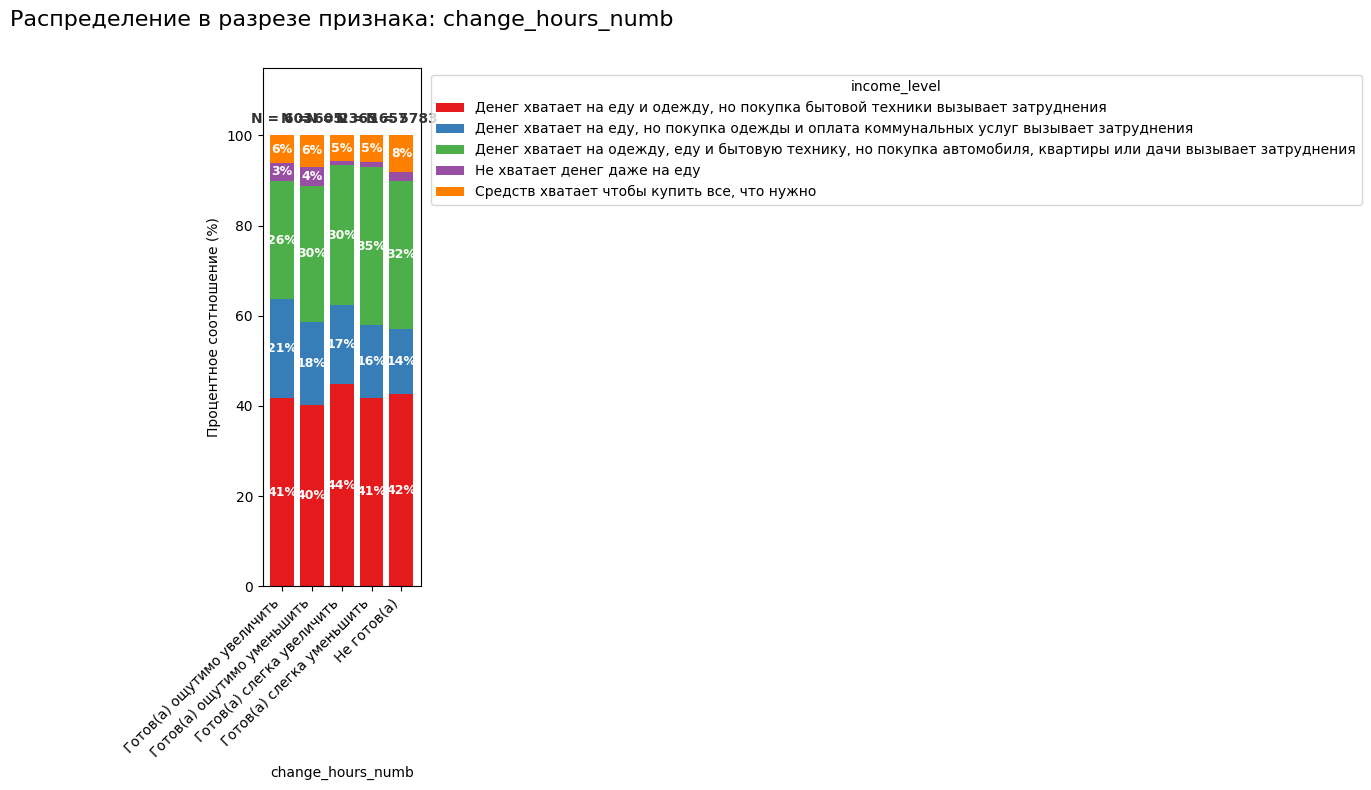

In [ ]:
get_differential_burnout_report('change_hours_numb', 'income_level', target_categories=['Средств хватает чтобы купить все, что нужно', 'Не хватает денег даже на еду'])

In [ ]:
columns = [ 'employment', 'employment2', 'satisfaction', 'state_at_the_moment', 'shift_org_1', 'shift_reg_1',
       'shift_spec_1', 'shift_prof_1', 'gender', 'age', 'org_type', 'qualification',  'wage_rate', 'condition_org',
       'academic_degree', 'home_duty', 'change_hours_numb', 'expectation_prof',
       'schedule',  'avr_work_hours_grouped' ]

#отдельно печатать 'income_level',
#регион - 1 в моей выборке
#specialization - слишком много признаков
#числовые - age_number, 'Длина коммента','exper', 'exper_org', 'exper_reg', 'avr_work_hours', 'future_prestige', 'future_equipment', 'future_comfort',
# числовые про удовлетворенность 'future_justice', 'future_social_help', 'future_organisation', 'future_selfgrowth', 'future_colleagues', 'future_leader',
# числовые про удовлетворенность 'future_corpprocess', 'future_information', 'future_schedule', 'future_riskinformation', 'future_interest', 'future_patients',
 # числовые про удовлетворенность    'future_region', 'future_region_healthcare'

#опросные фичи 'edu_1', 'edu_2', 'edu_3', 'edu_4', 'edu_5', 'edu_6', 'edu_7', 'edu_8', 'edu_9', 'edu_10', 'edu_11', 'edu_12',
#агрегаты 'burnout1_desc', 'burnout1_exh', 'burnout1_dist', 'burnout1_cog','burnout1_emt', 'burnout1_integral','burnout1_integral_num'

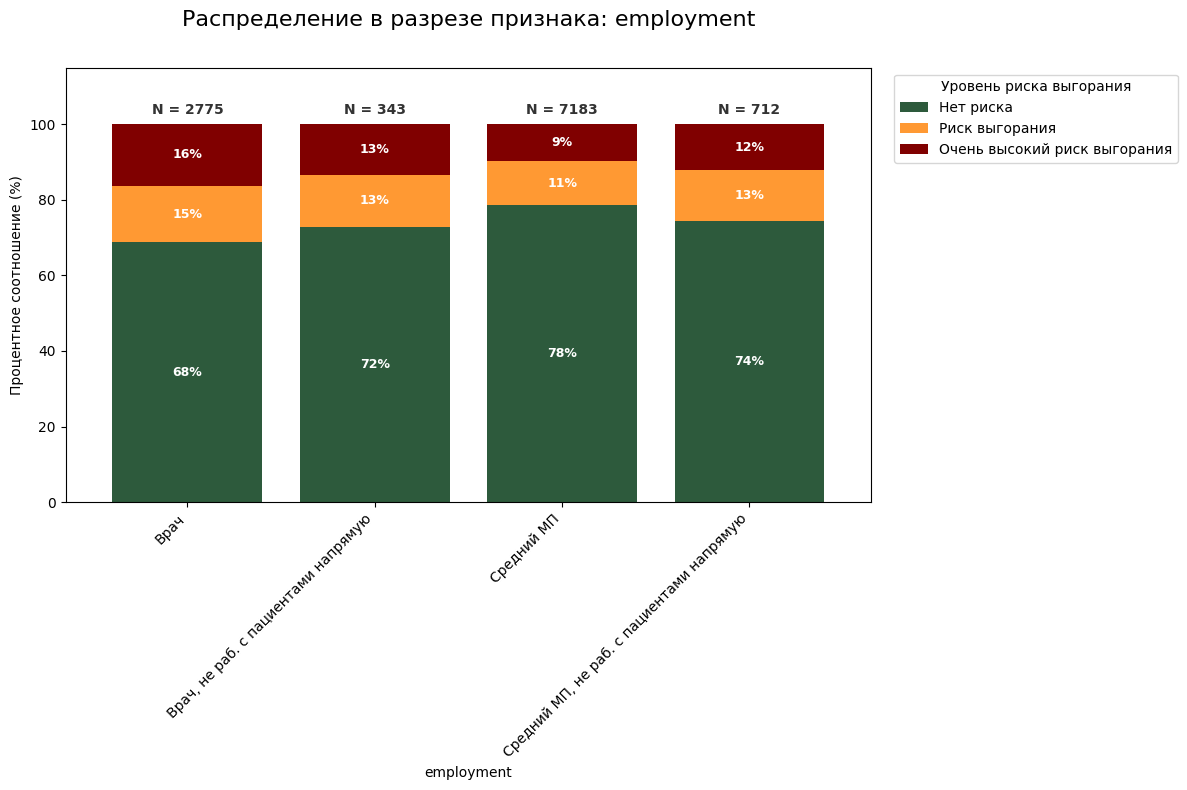


Анализ по категории: 'Очень высокий риск выгорания'
Порог Бонферрони (0.05 / 6): 0.00833
Найдено значимых различий: 2 из 6



,Пара групп,p-value,Значимо (Бонферрони)
1,Врач vs Средний МП,0.00,True
2,"Врач vs Средний МП, не раб. с пациентами напрямую",0.01,True


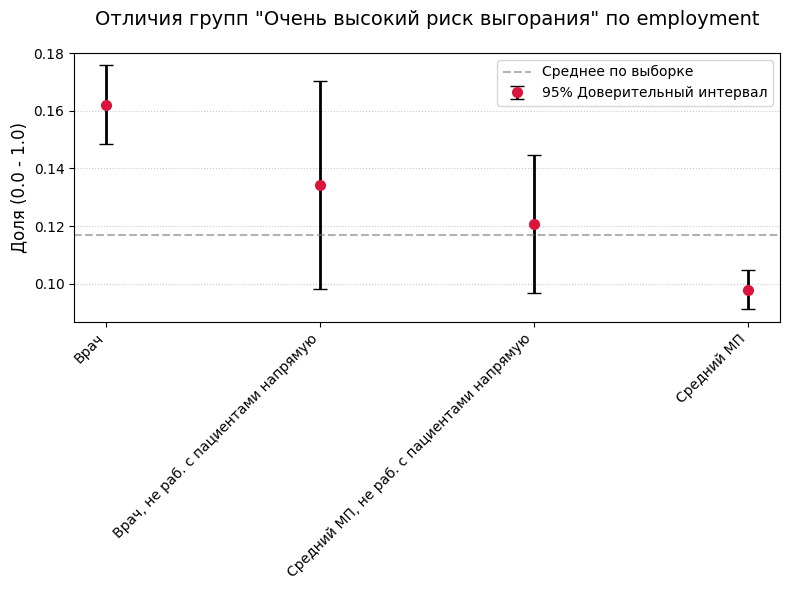

Анализ по категории: 'Риск выгорания'
Порог Бонферрони (0.05 / 6): 0.00833
Найдено значимых различий: 1 из 6



,Пара групп,p-value,Значимо (Бонферрони)
1,Врач vs Средний МП,0.00,True


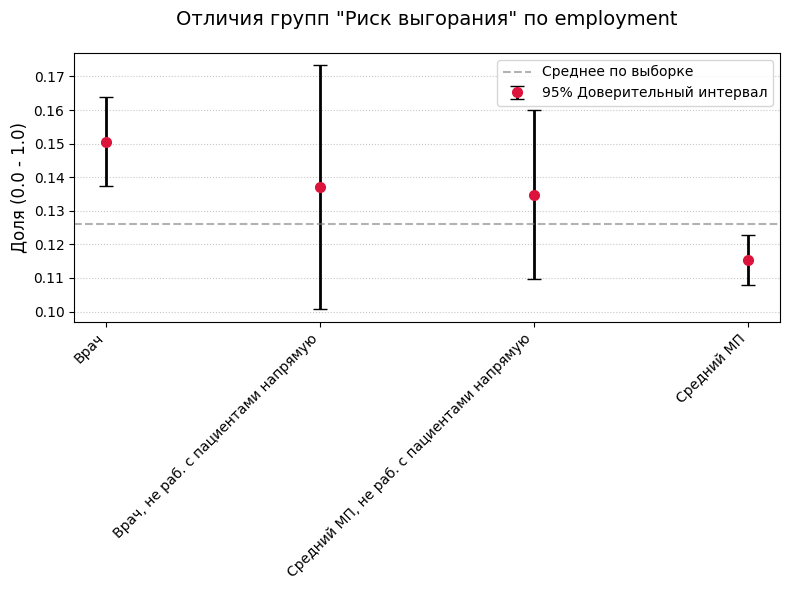

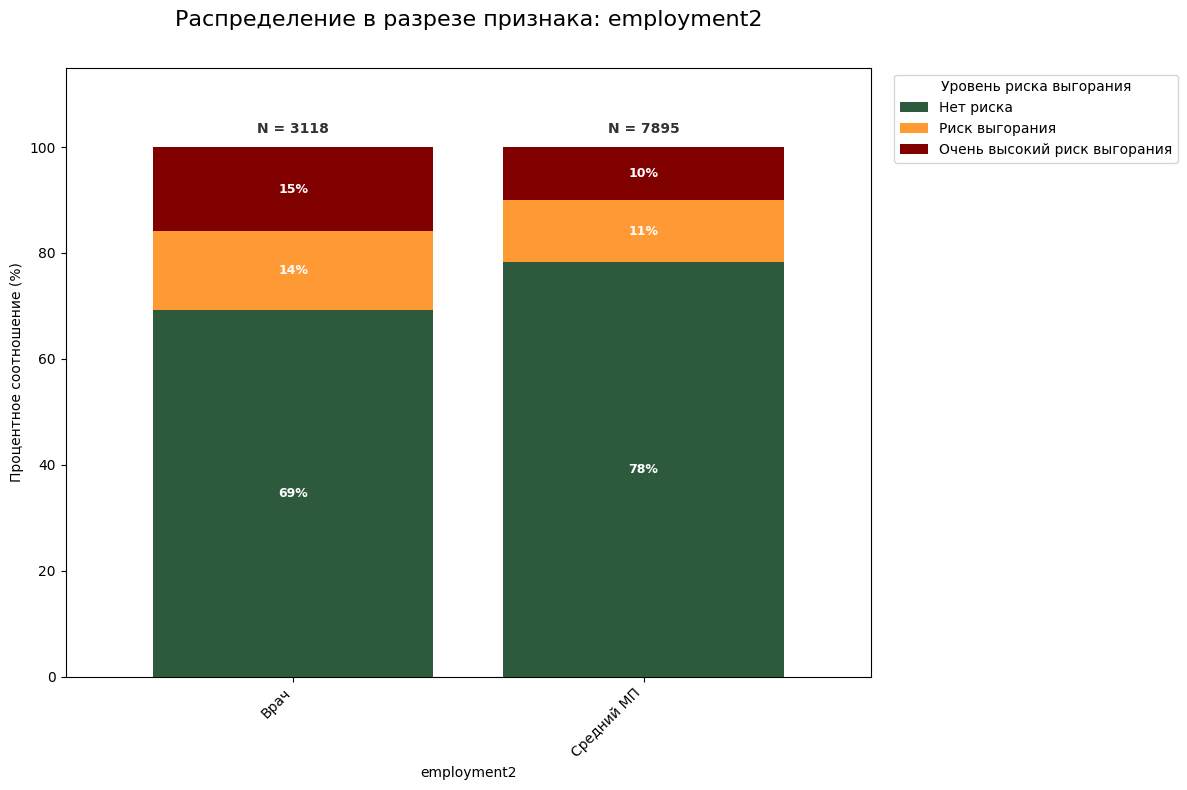


Анализ по категории: 'Очень высокий риск выгорания'
Порог Бонферрони (0.05 / 1): 0.05000
Найдено значимых различий: 1 из 1



,Пара групп,p-value,Значимо (Бонферрони)
0,Врач vs Средний МП,0.00,True


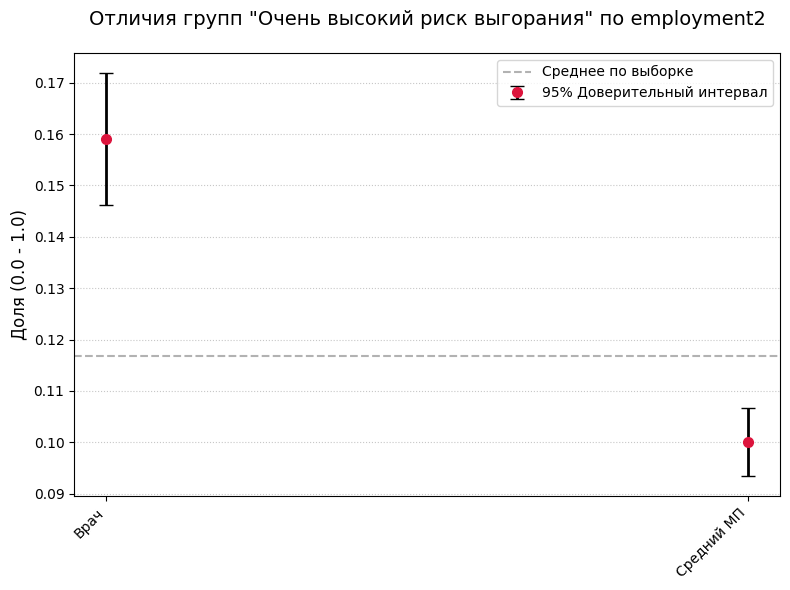

Анализ по категории: 'Риск выгорания'
Порог Бонферрони (0.05 / 1): 0.05000
Найдено значимых различий: 1 из 1



,Пара групп,p-value,Значимо (Бонферрони)
0,Врач vs Средний МП,0.00,True


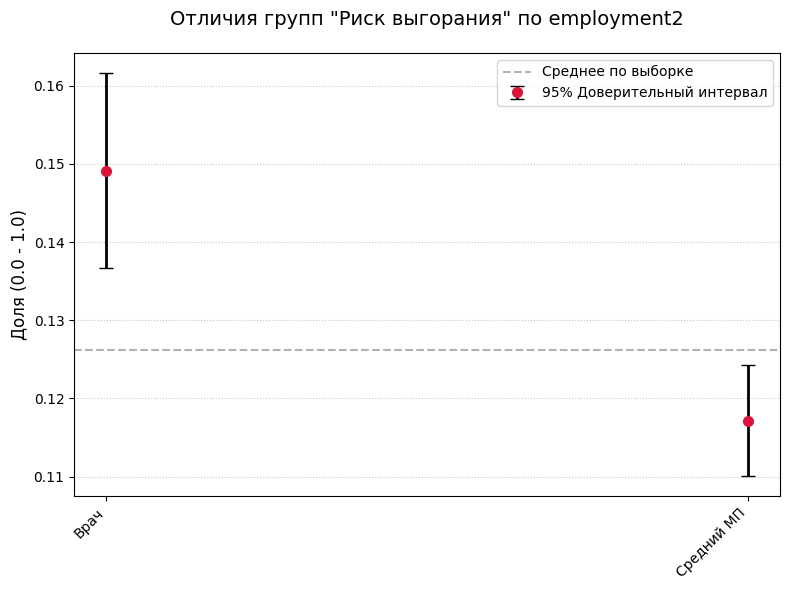

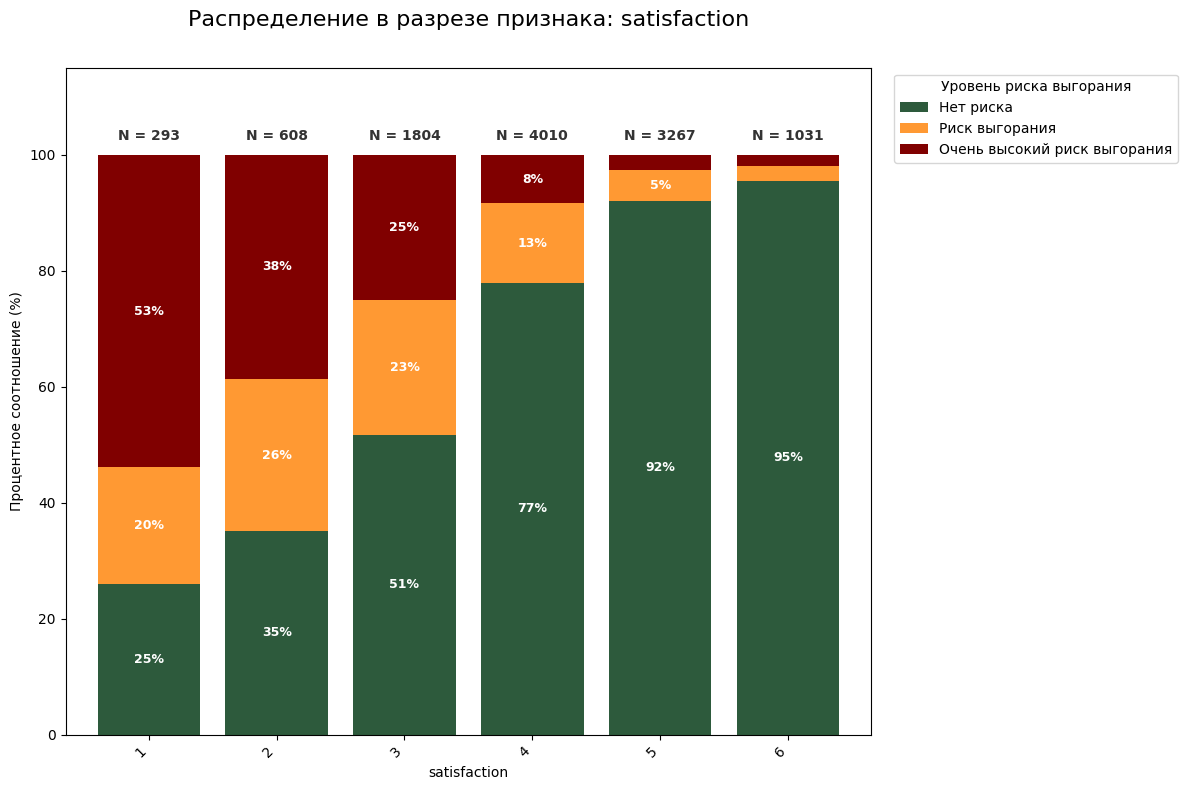


Анализ по категории: 'Очень высокий риск выгорания'
Порог Бонферрони (0.05 / 15): 0.00333
Найдено значимых различий: 14 из 15



,Пара групп,p-value,Значимо (Бонферрони)
1,1 vs 3,0.00,True
2,1 vs 4,0.00,True
3,1 vs 5,0.00,True
4,1 vs 6,0.00,True
6,2 vs 4,0.00,True
5,2 vs 3,0.00,True
7,2 vs 5,0.00,True
8,2 vs 6,0.00,True
12,4 vs 5,0.00,True
9,3 vs 4,0.00,True


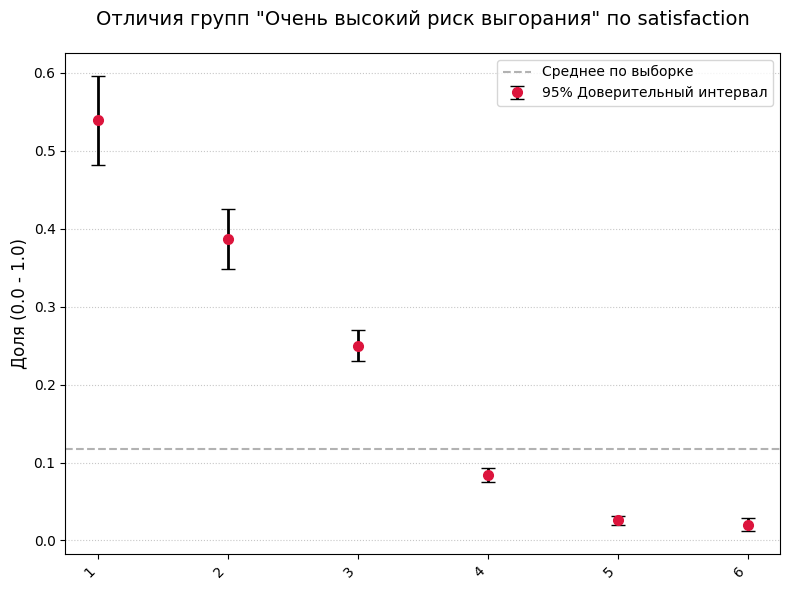

Анализ по категории: 'Риск выгорания'
Порог Бонферрони (0.05 / 15): 0.00333
Найдено значимых различий: 12 из 15



,Пара групп,p-value,Значимо (Бонферрони)
3,1 vs 5,0.00,True
4,1 vs 6,0.00,True
6,2 vs 4,0.00,True
7,2 vs 5,0.00,True
9,3 vs 4,0.00,True
8,2 vs 6,0.00,True
10,3 vs 5,0.00,True
11,3 vs 6,0.00,True
13,4 vs 6,0.00,True
12,4 vs 5,0.00,True


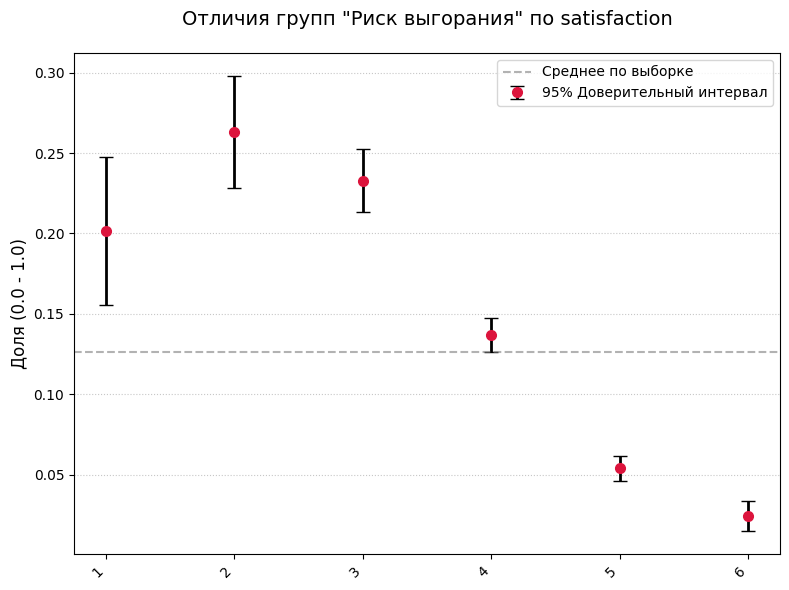

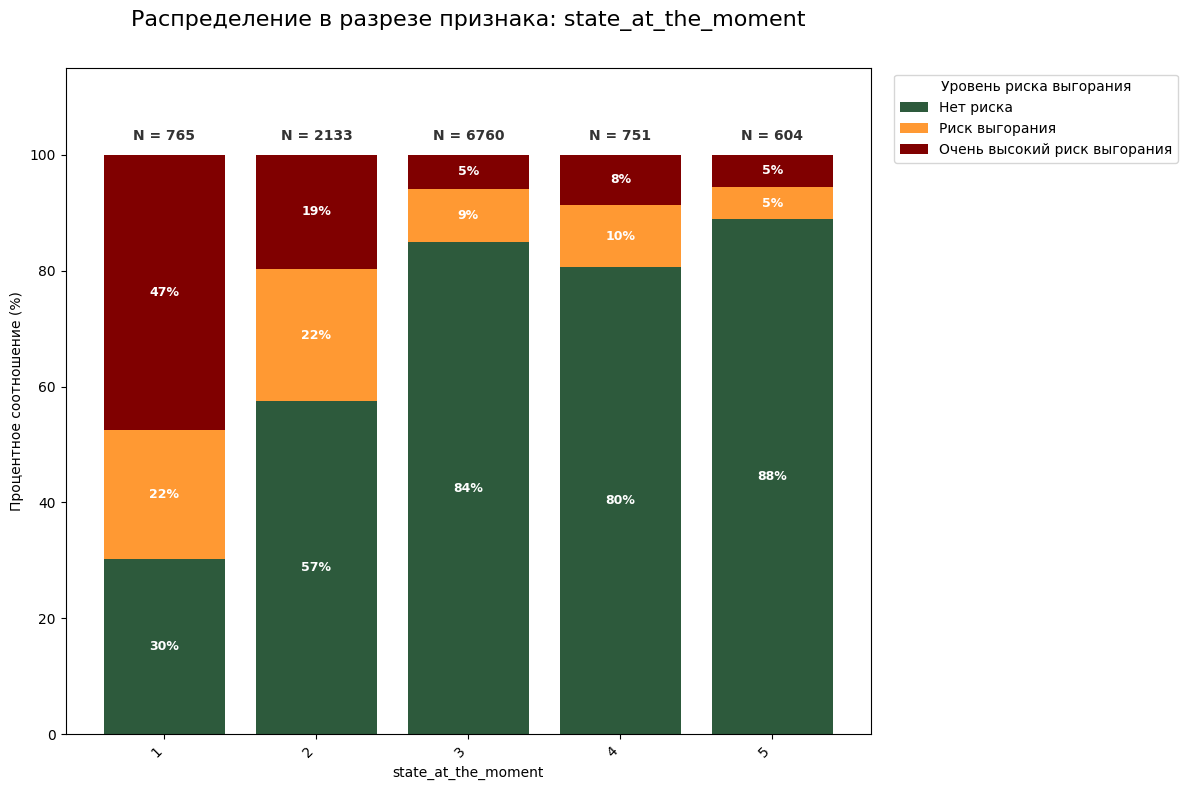


Анализ по категории: 'Очень высокий риск выгорания'
Порог Бонферрони (0.05 / 10): 0.00500
Найдено значимых различий: 8 из 10



,Пара групп,p-value,Значимо (Бонферрони)
0,1 vs 2,0.00,True
1,1 vs 3,0.00,True
2,1 vs 4,0.00,True
3,1 vs 5,0.00,True
4,2 vs 3,0.00,True
5,2 vs 4,0.00,True
6,2 vs 5,0.00,True
7,3 vs 4,0.00,True


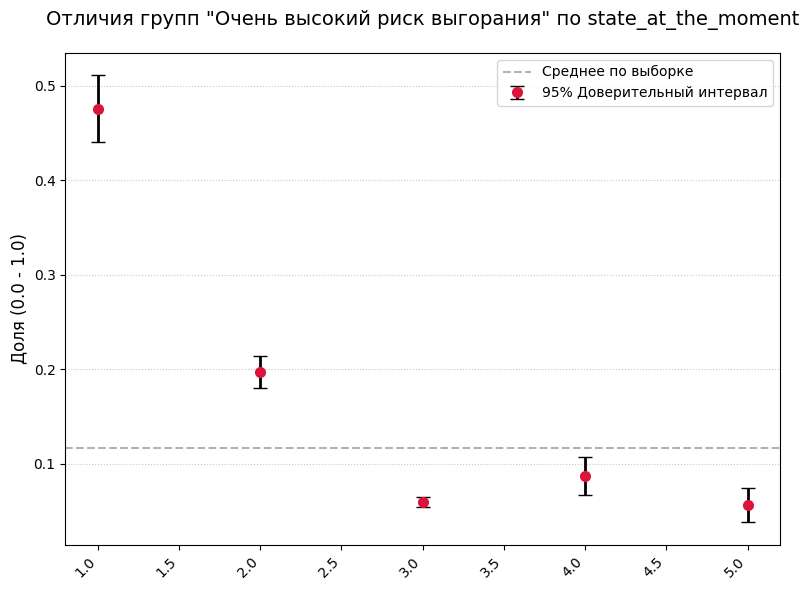

Анализ по категории: 'Риск выгорания'
Порог Бонферрони (0.05 / 10): 0.00500
Найдено значимых различий: 8 из 10



,Пара групп,p-value,Значимо (Бонферрони)
1,1 vs 3,0.00,True
2,1 vs 4,0.00,True
3,1 vs 5,0.00,True
4,2 vs 3,0.00,True
5,2 vs 4,0.00,True
6,2 vs 5,0.00,True
9,4 vs 5,0.00,True
8,3 vs 5,0.00,True


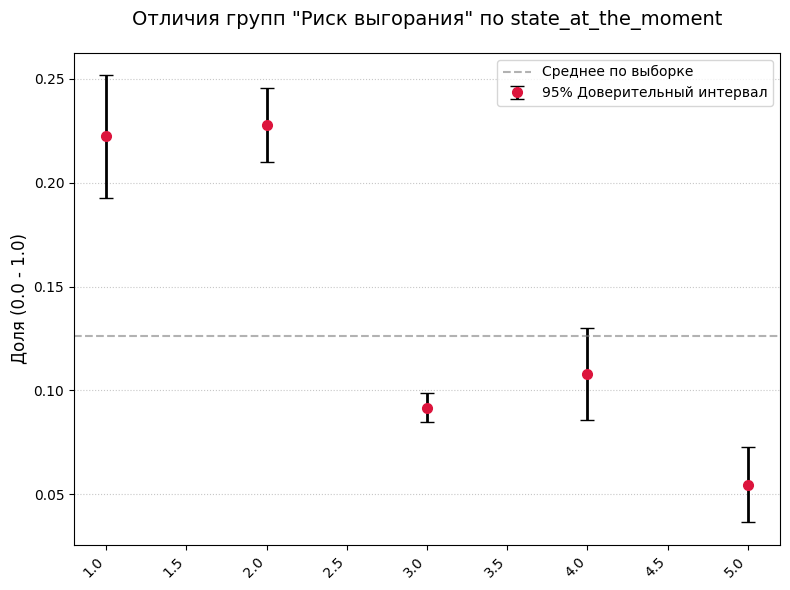

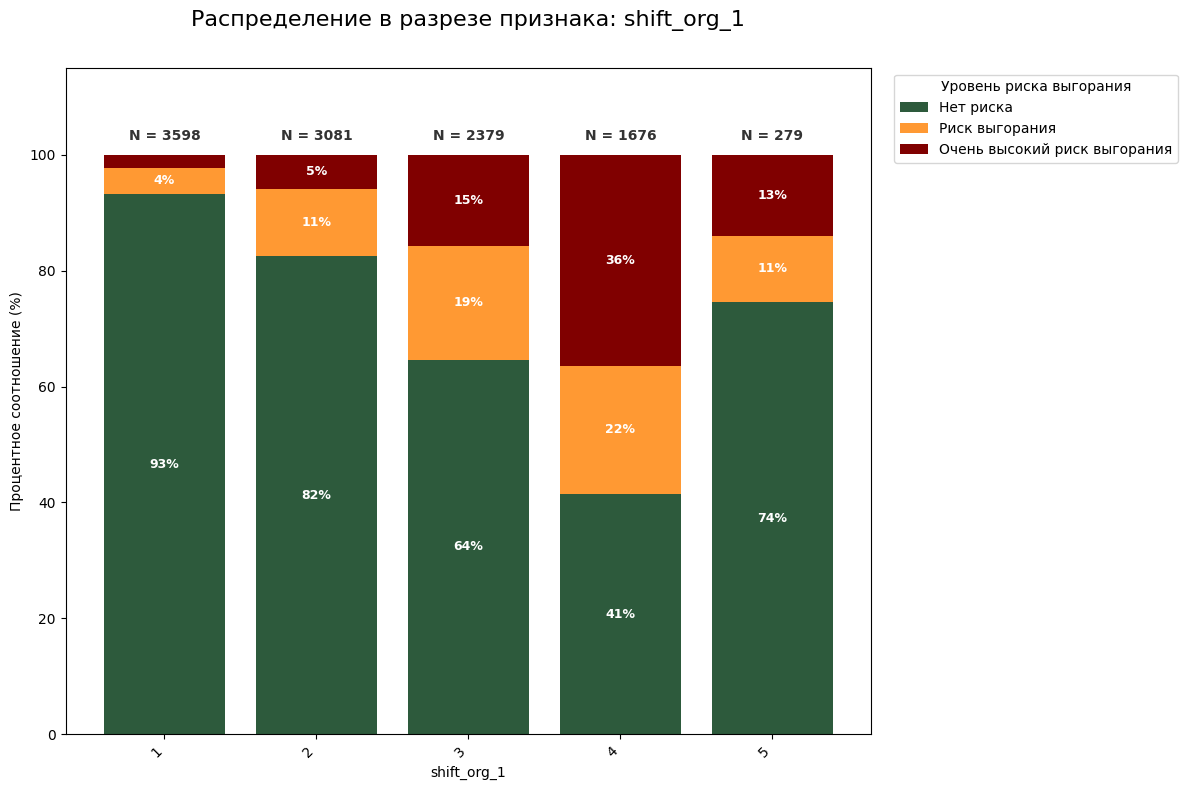


Анализ по категории: 'Очень высокий риск выгорания'
Порог Бонферрони (0.05 / 10): 0.00500
Найдено значимых различий: 9 из 10



,Пара групп,p-value,Значимо (Бонферрони)
0,1 vs 2,0.00,True
1,1 vs 3,0.00,True
2,1 vs 4,0.00,True
3,1 vs 5,0.00,True
4,2 vs 3,0.00,True
5,2 vs 4,0.00,True
7,3 vs 4,0.00,True
9,4 vs 5,0.00,True
6,2 vs 5,0.00,True


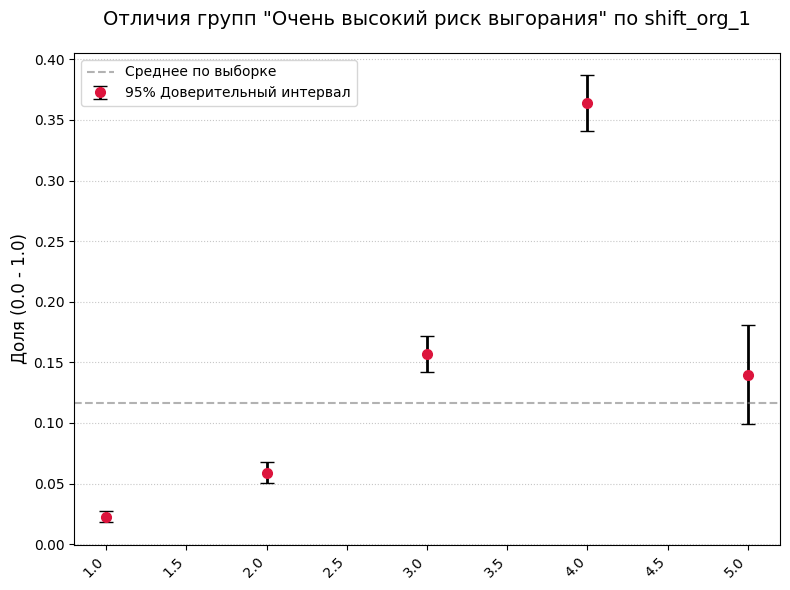

Анализ по категории: 'Риск выгорания'
Порог Бонферрони (0.05 / 10): 0.00500
Найдено значимых различий: 8 из 10



,Пара групп,p-value,Значимо (Бонферрони)
0,1 vs 2,0.00,True
1,1 vs 3,0.00,True
2,1 vs 4,0.00,True
4,2 vs 3,0.00,True
5,2 vs 4,0.00,True
3,1 vs 5,0.00,True
9,4 vs 5,0.00,True
8,3 vs 5,0.00,True


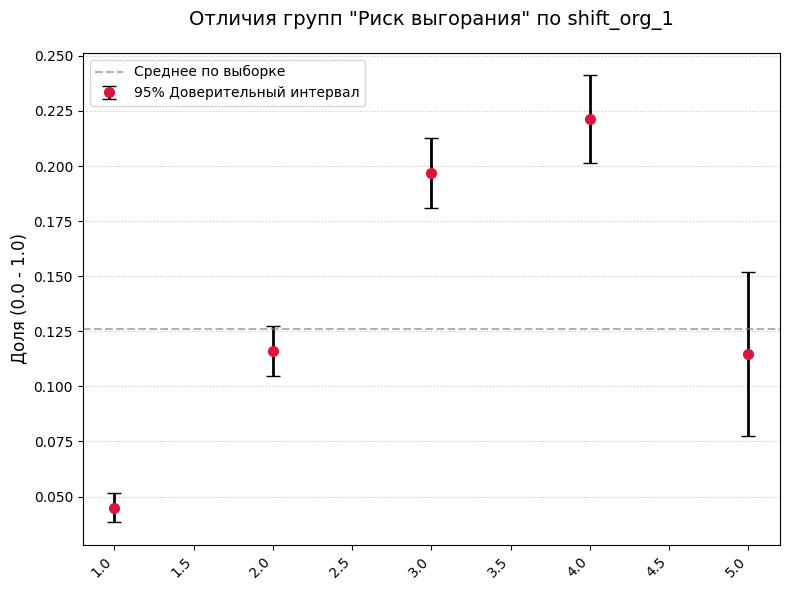

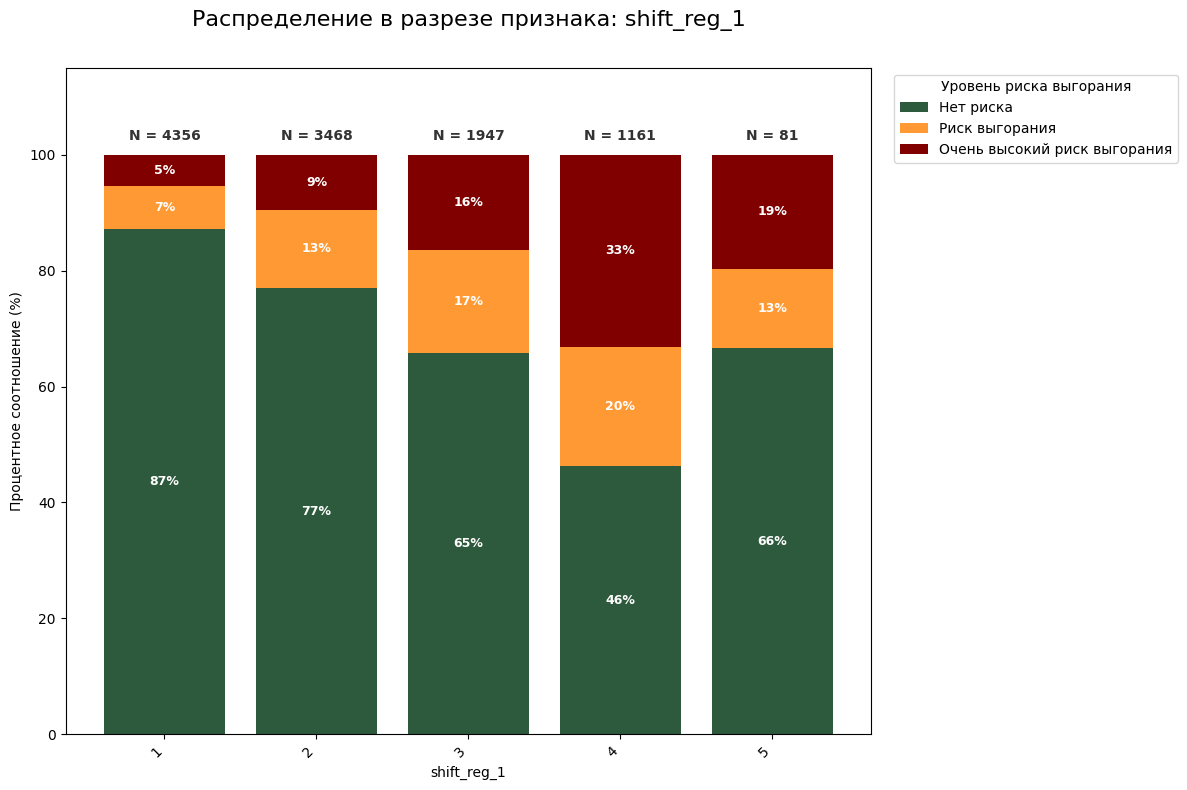


Анализ по категории: 'Очень высокий риск выгорания'
Порог Бонферрони (0.05 / 10): 0.00500
Найдено значимых различий: 8 из 10



,Пара групп,p-value,Значимо (Бонферрони)
0,1 vs 2,0.00,True
1,1 vs 3,0.00,True
2,1 vs 4,0.00,True
4,2 vs 3,0.00,True
7,3 vs 4,0.00,True
5,2 vs 4,0.00,True
3,1 vs 5,0.00,True
6,2 vs 5,0.00,True


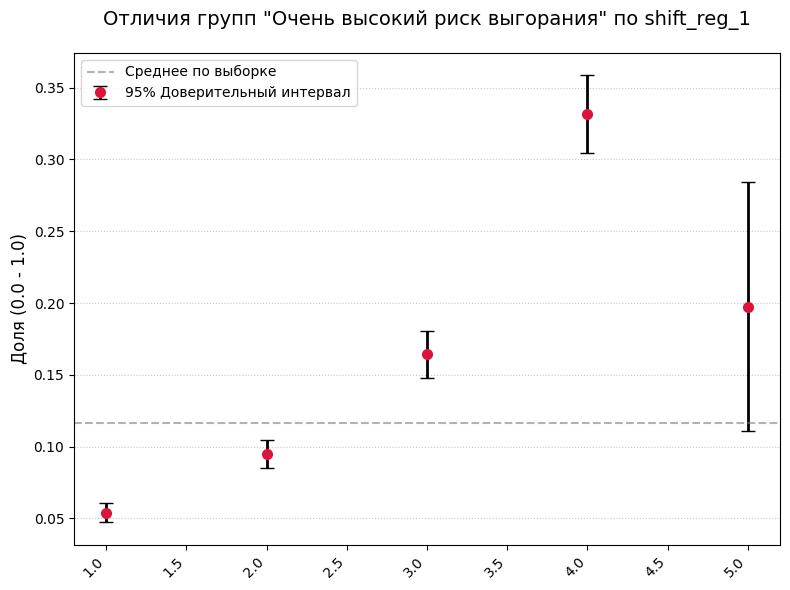

Анализ по категории: 'Риск выгорания'
Порог Бонферрони (0.05 / 10): 0.00500
Найдено значимых различий: 5 из 10



,Пара групп,p-value,Значимо (Бонферрони)
0,1 vs 2,0.00,True
1,1 vs 3,0.00,True
2,1 vs 4,0.00,True
5,2 vs 4,0.00,True
4,2 vs 3,0.00,True


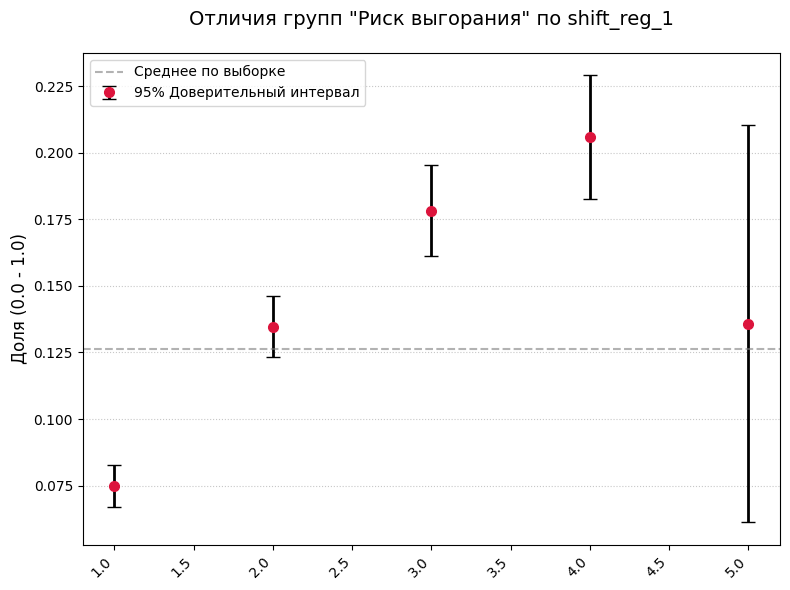

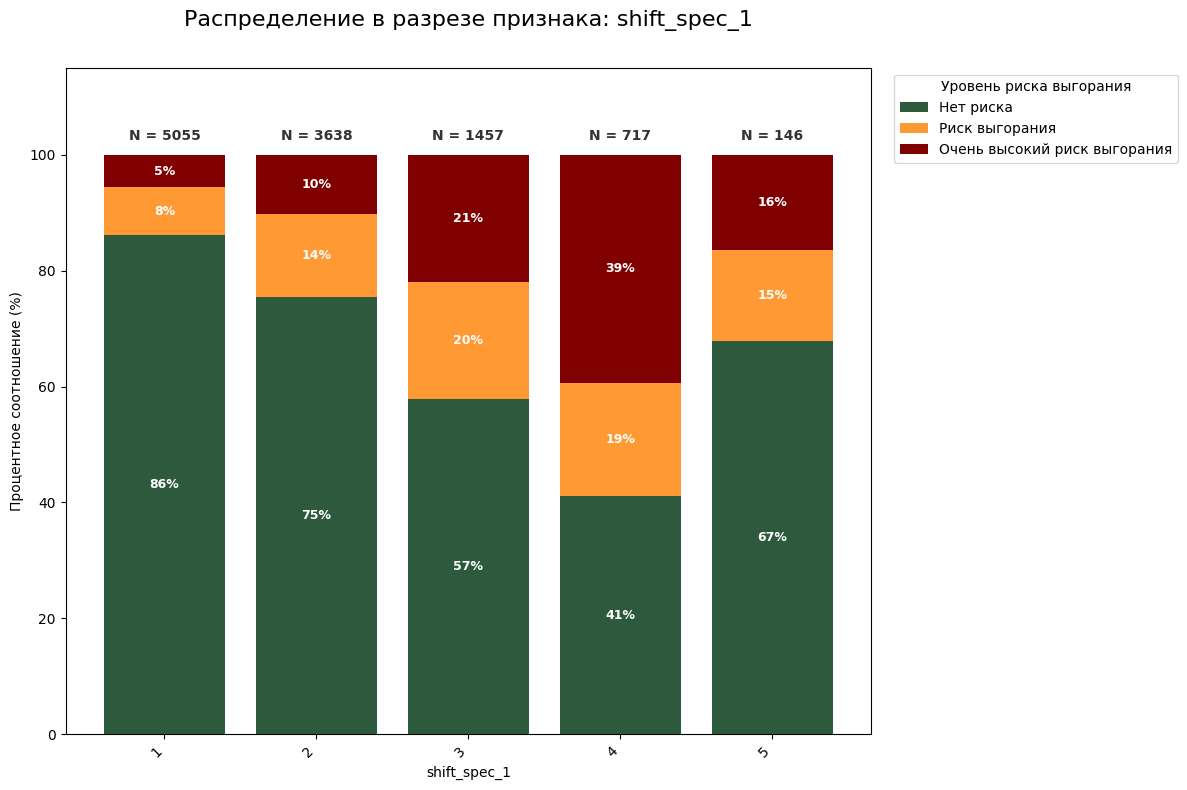


Анализ по категории: 'Очень высокий риск выгорания'
Порог Бонферрони (0.05 / 10): 0.00500
Найдено значимых различий: 8 из 10



,Пара групп,p-value,Значимо (Бонферрони)
0,1 vs 2,0.00,True
1,1 vs 3,0.00,True
2,1 vs 4,0.00,True
4,2 vs 3,0.00,True
7,3 vs 4,0.00,True
5,2 vs 4,0.00,True
3,1 vs 5,0.00,True
9,4 vs 5,0.00,True


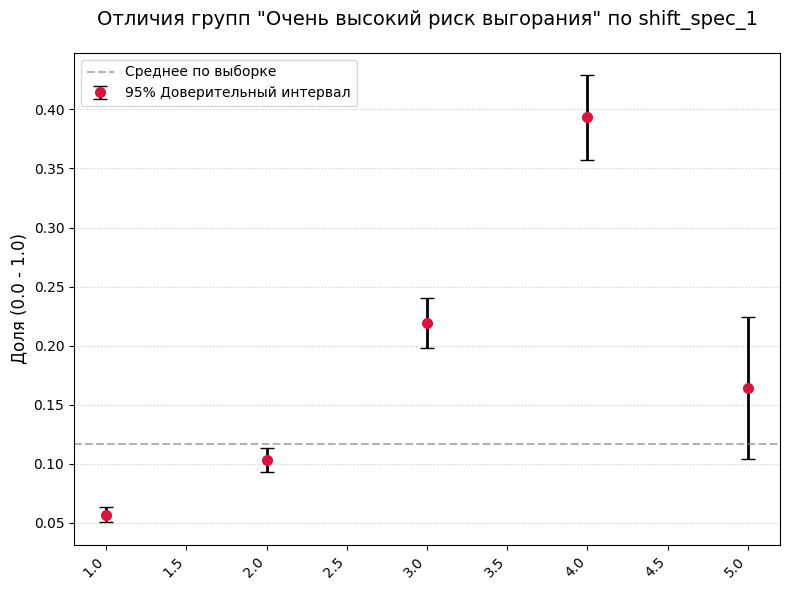

Анализ по категории: 'Риск выгорания'
Порог Бонферрони (0.05 / 10): 0.00500
Найдено значимых различий: 6 из 10



,Пара групп,p-value,Значимо (Бонферрони)
0,1 vs 2,0.00,True
1,1 vs 3,0.00,True
2,1 vs 4,0.00,True
4,2 vs 3,0.00,True
5,2 vs 4,0.00,True
3,1 vs 5,0.00,True


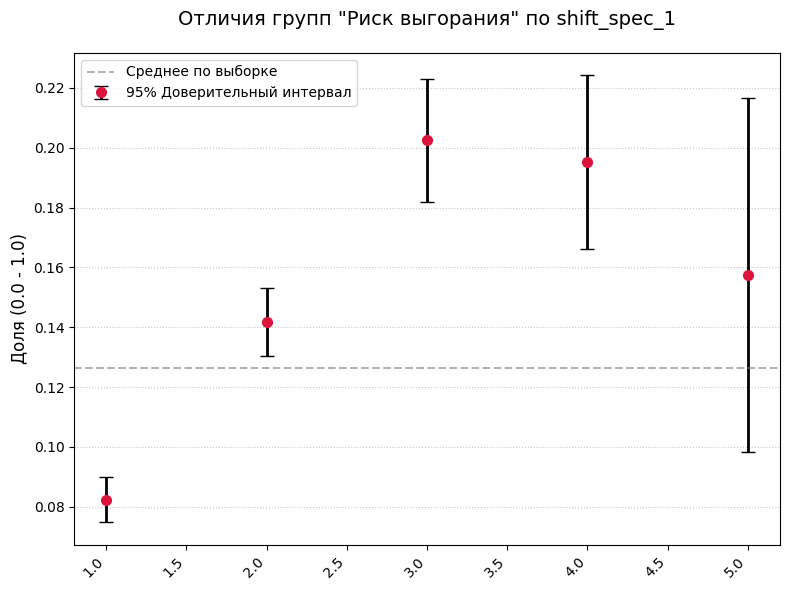

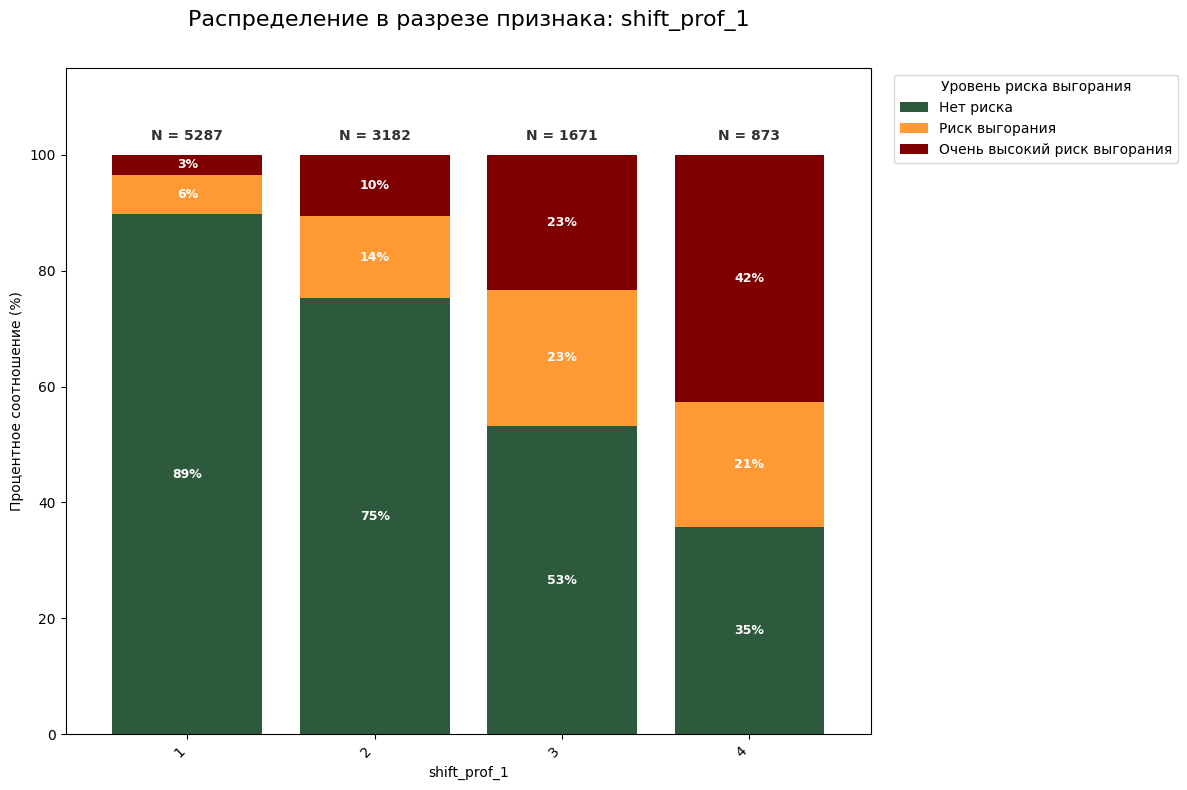


Анализ по категории: 'Очень высокий риск выгорания'
Порог Бонферрони (0.05 / 6): 0.00833
Найдено значимых различий: 6 из 6



,Пара групп,p-value,Значимо (Бонферрони)
0,1 vs 2,0.00,True
1,1 vs 3,0.00,True
2,1 vs 4,0.00,True
3,2 vs 3,0.00,True
4,2 vs 4,0.00,True
5,3 vs 4,0.00,True


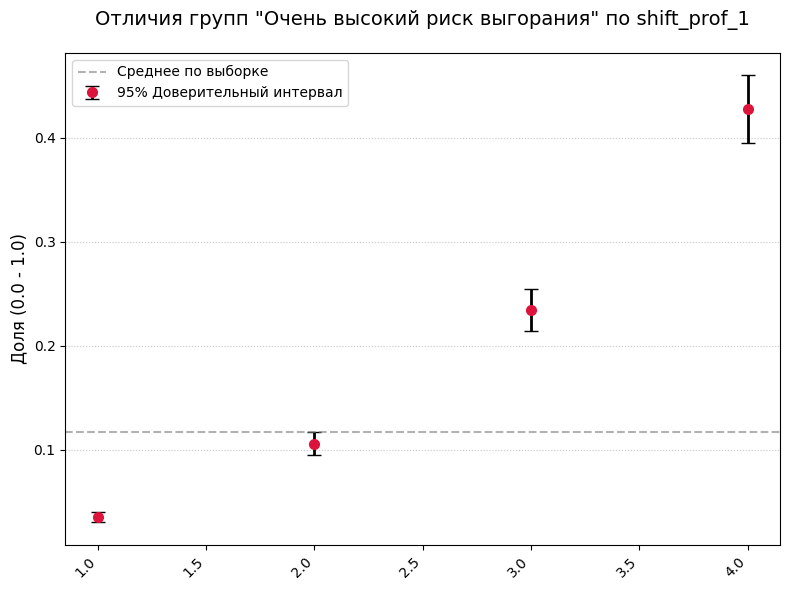

Анализ по категории: 'Риск выгорания'
Порог Бонферрони (0.05 / 6): 0.00833
Найдено значимых различий: 5 из 6



,Пара групп,p-value,Значимо (Бонферрони)
0,1 vs 2,0.00,True
1,1 vs 3,0.00,True
2,1 vs 4,0.00,True
3,2 vs 3,0.00,True
4,2 vs 4,0.00,True


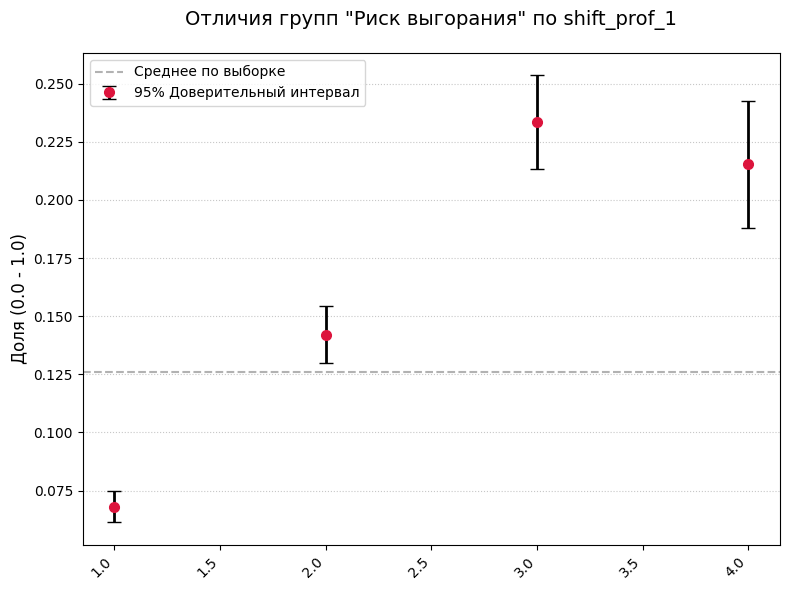

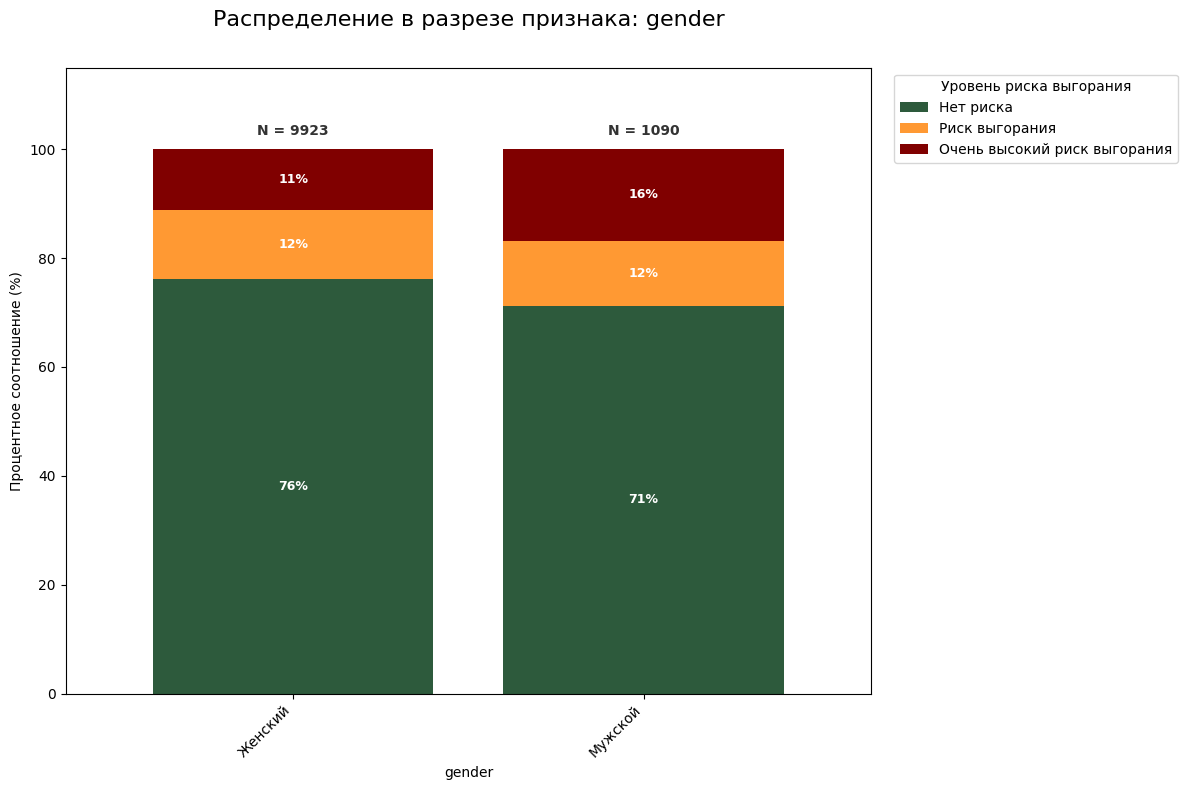


Анализ по категории: 'Очень высокий риск выгорания'
Порог Бонферрони (0.05 / 1): 0.05000
Найдено значимых различий: 1 из 1



,Пара групп,p-value,Значимо (Бонферрони)
0,Женский vs Мужской,0.00,True


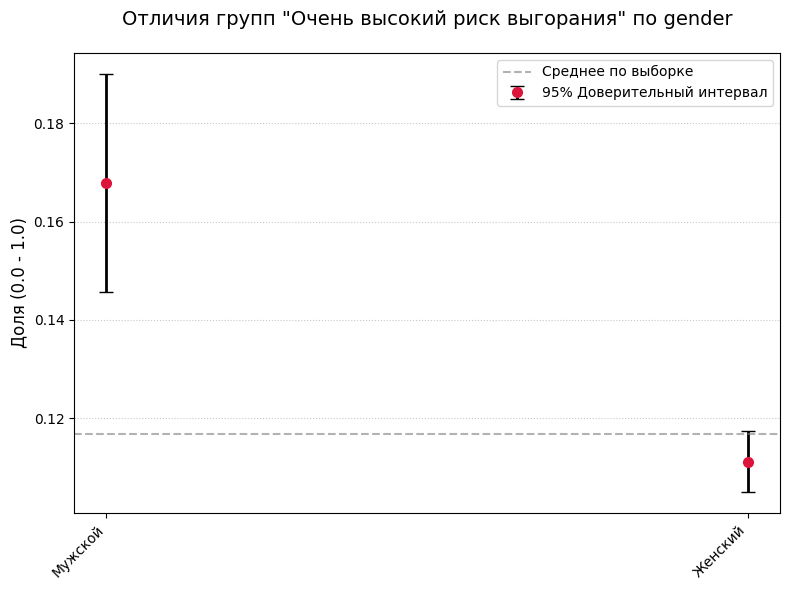

Анализ по категории: 'Риск выгорания'
Порог Бонферрони (0.05 / 1): 0.05000
Найдено значимых различий: 0 из 1



,Пара групп,p-value,Значимо (Бонферрони)


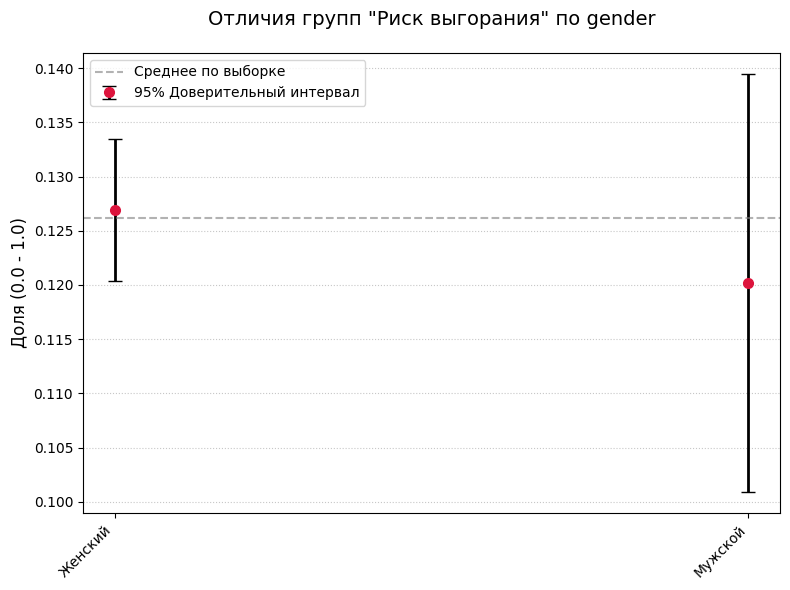

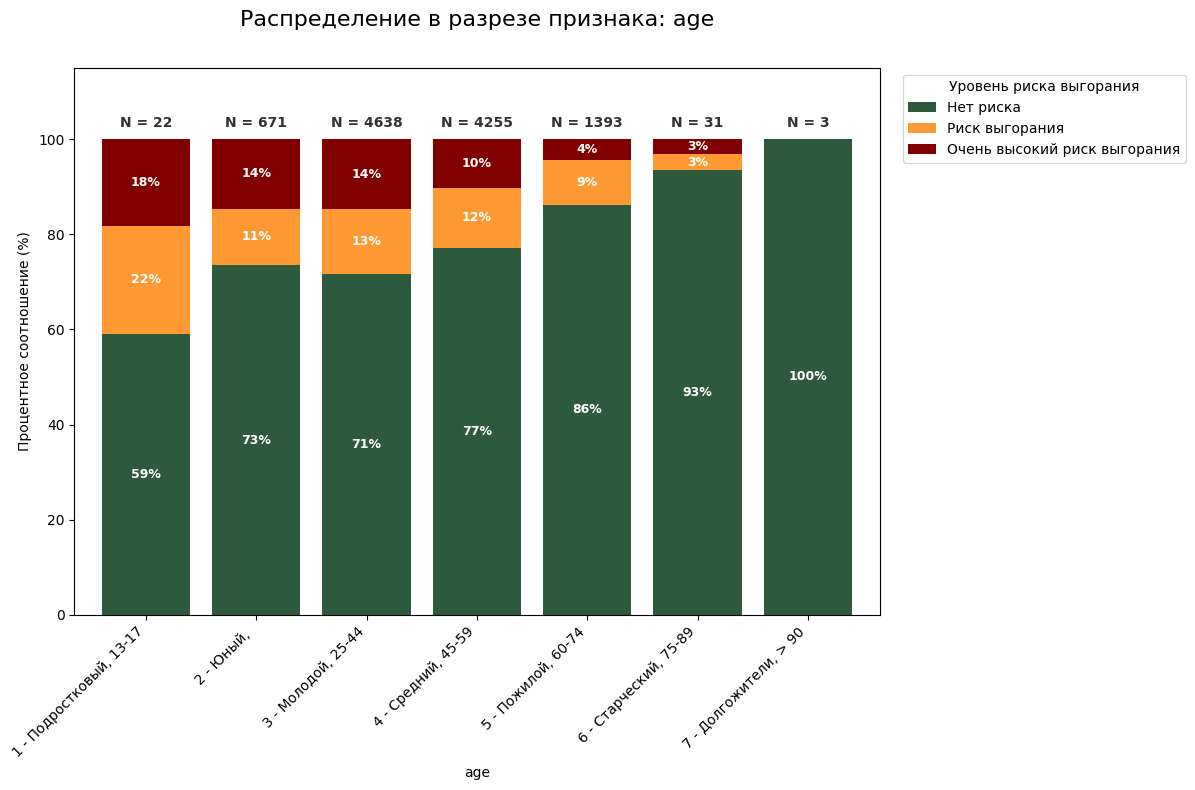


Анализ по категории: 'Очень высокий риск выгорания'
Порог Бонферрони (0.05 / 21): 0.00238
Найдено значимых различий: 5 из 21



,Пара групп,p-value,Значимо (Бонферрони)
8,"2 - Юный, vs 5 - Пожилой, 60-74",0.00,True
11,"3 - Молодой, 25-44 vs 4 - Средний, 45-59",0.00,True
12,"3 - Молодой, 25-44 vs 5 - Пожилой, 60-74",0.00,True
15,"4 - Средний, 45-59 vs 5 - Пожилой, 60-74",0.00,True
7,"2 - Юный, vs 4 - Средний, 45-59",0.00,True


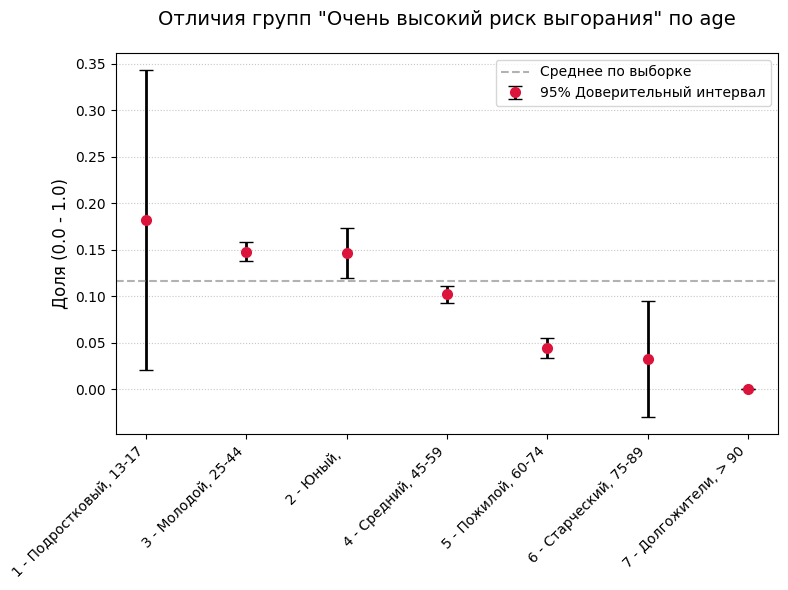

Анализ по категории: 'Риск выгорания'
Порог Бонферрони (0.05 / 21): 0.00238
Найдено значимых различий: 2 из 21



,Пара групп,p-value,Значимо (Бонферрони)
12,"3 - Молодой, 25-44 vs 5 - Пожилой, 60-74",0.00,True
15,"4 - Средний, 45-59 vs 5 - Пожилой, 60-74",0.00,True


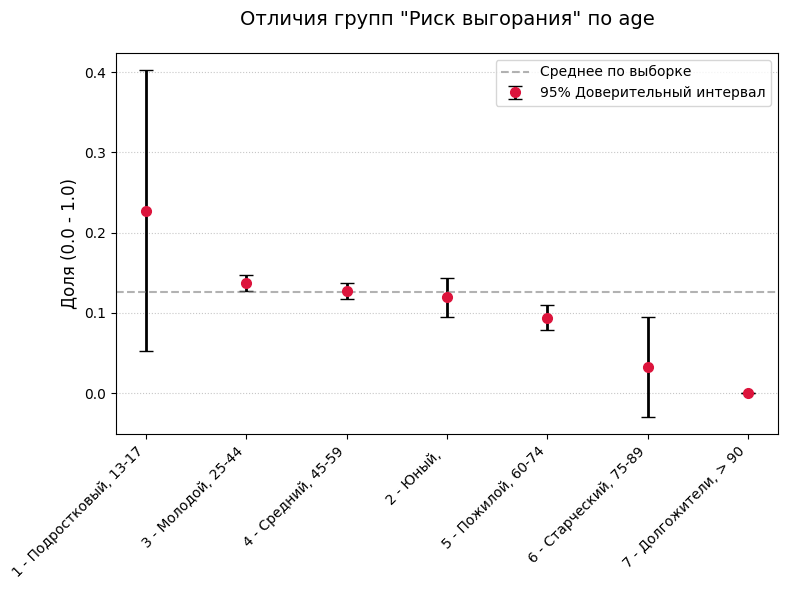

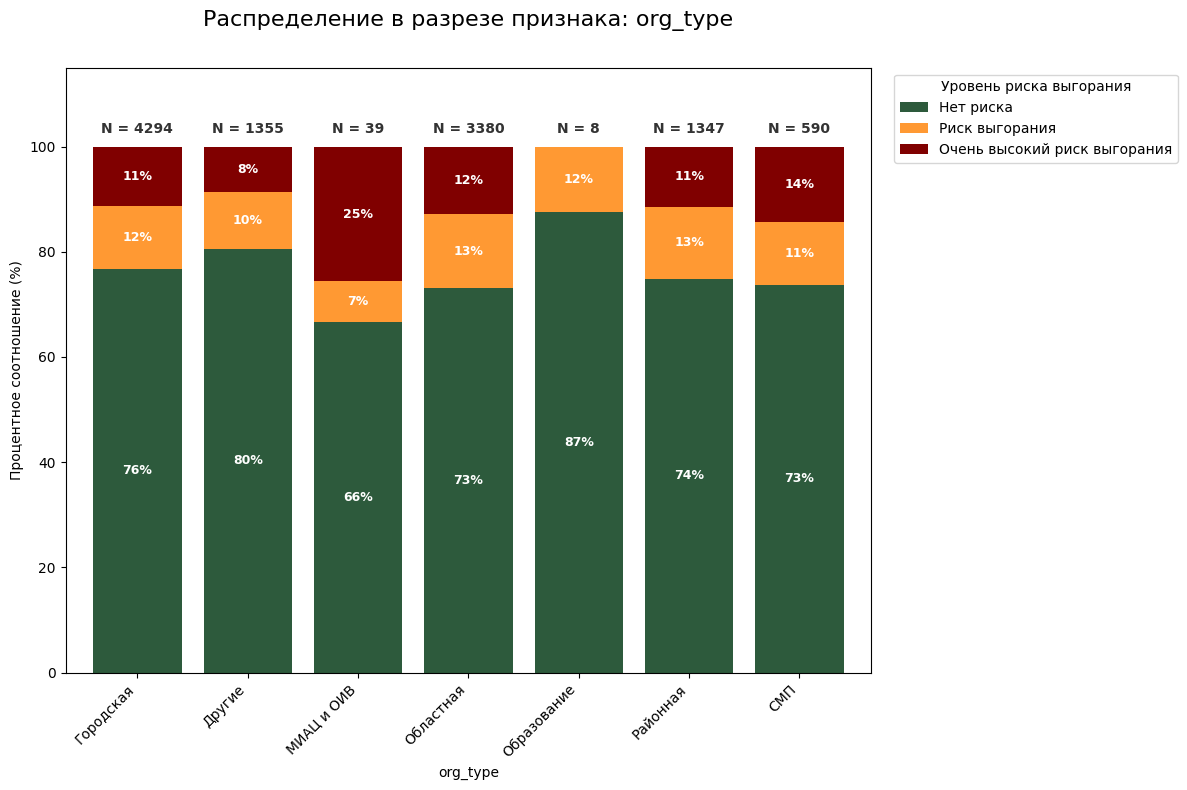


Анализ по категории: 'Очень высокий риск выгорания'
Порог Бонферрони (0.05 / 21): 0.00238
Найдено значимых различий: 3 из 21



,Пара групп,p-value,Значимо (Бонферрони)
7,Другие vs Областная,0.00,True
10,Другие vs СМП,0.00,True
6,Другие vs МИАЦ и ОИВ,0.00,True


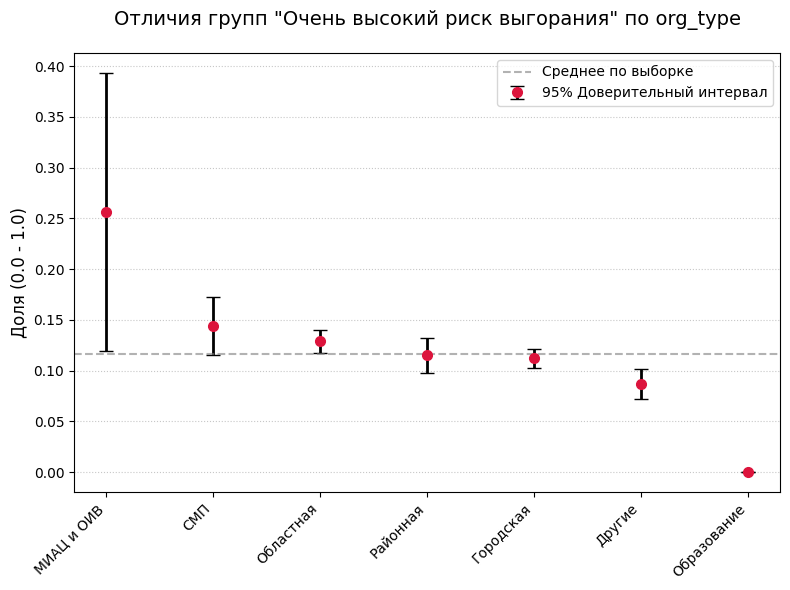

Анализ по категории: 'Риск выгорания'
Порог Бонферрони (0.05 / 21): 0.00238
Найдено значимых различий: 0 из 21



,Пара групп,p-value,Значимо (Бонферрони)


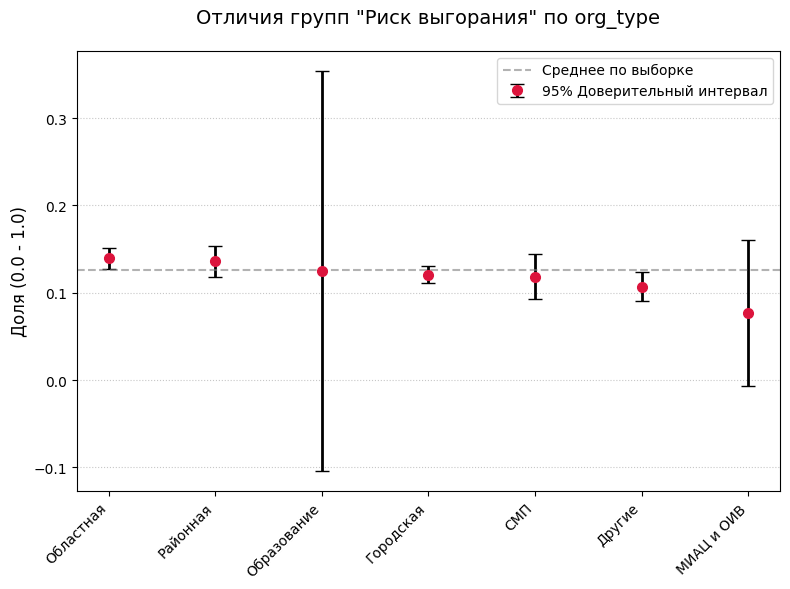

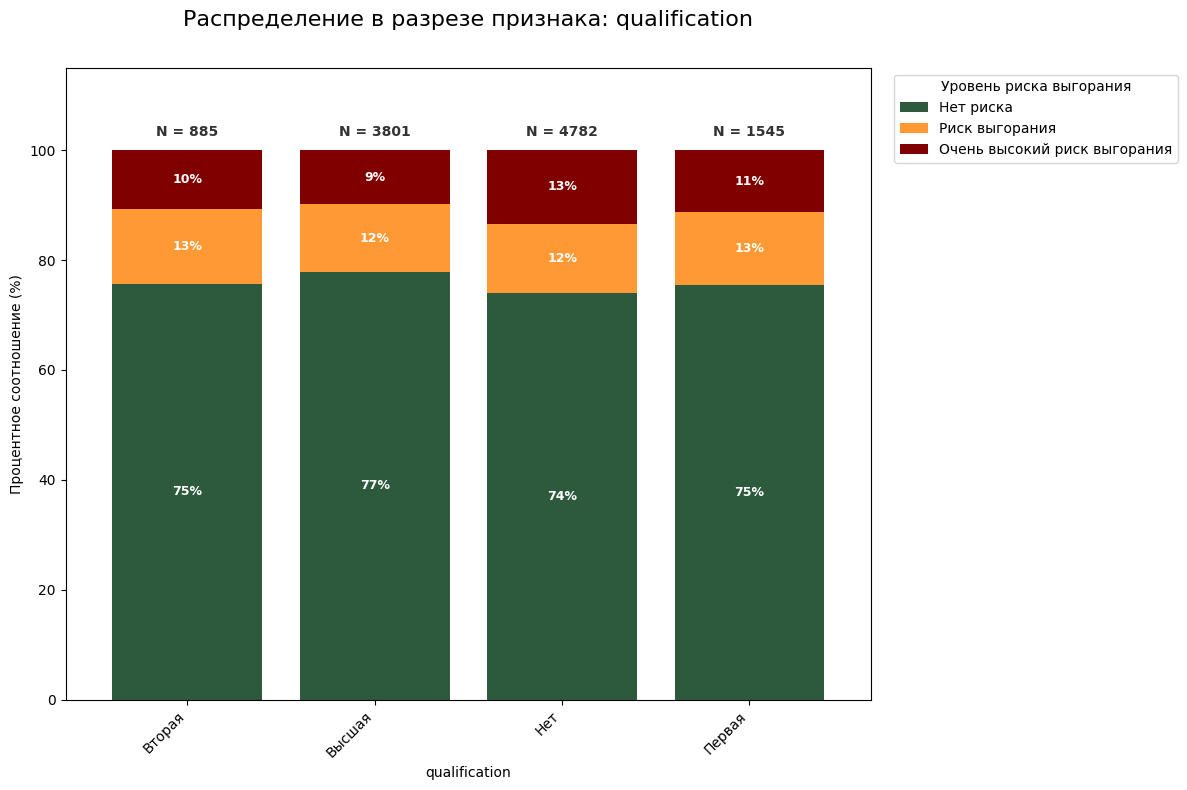


Анализ по категории: 'Очень высокий риск выгорания'
Порог Бонферрони (0.05 / 6): 0.00833
Найдено значимых различий: 1 из 6



,Пара групп,p-value,Значимо (Бонферрони)
3,Высшая vs Нет,0.00,True


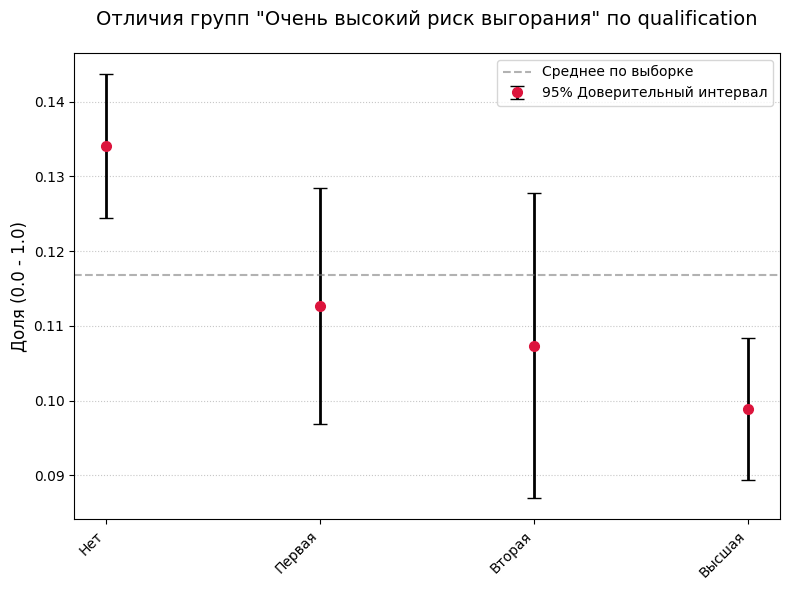

Анализ по категории: 'Риск выгорания'
Порог Бонферрони (0.05 / 6): 0.00833
Найдено значимых различий: 0 из 6



,Пара групп,p-value,Значимо (Бонферрони)


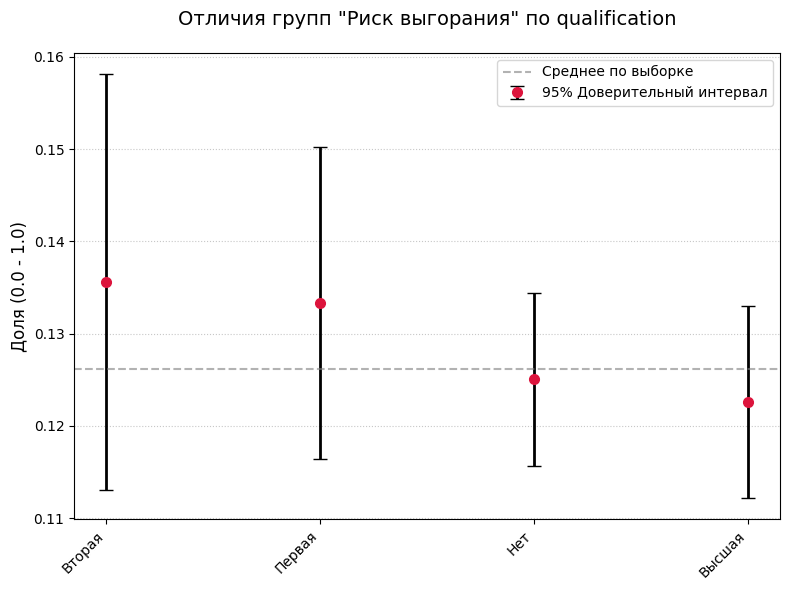

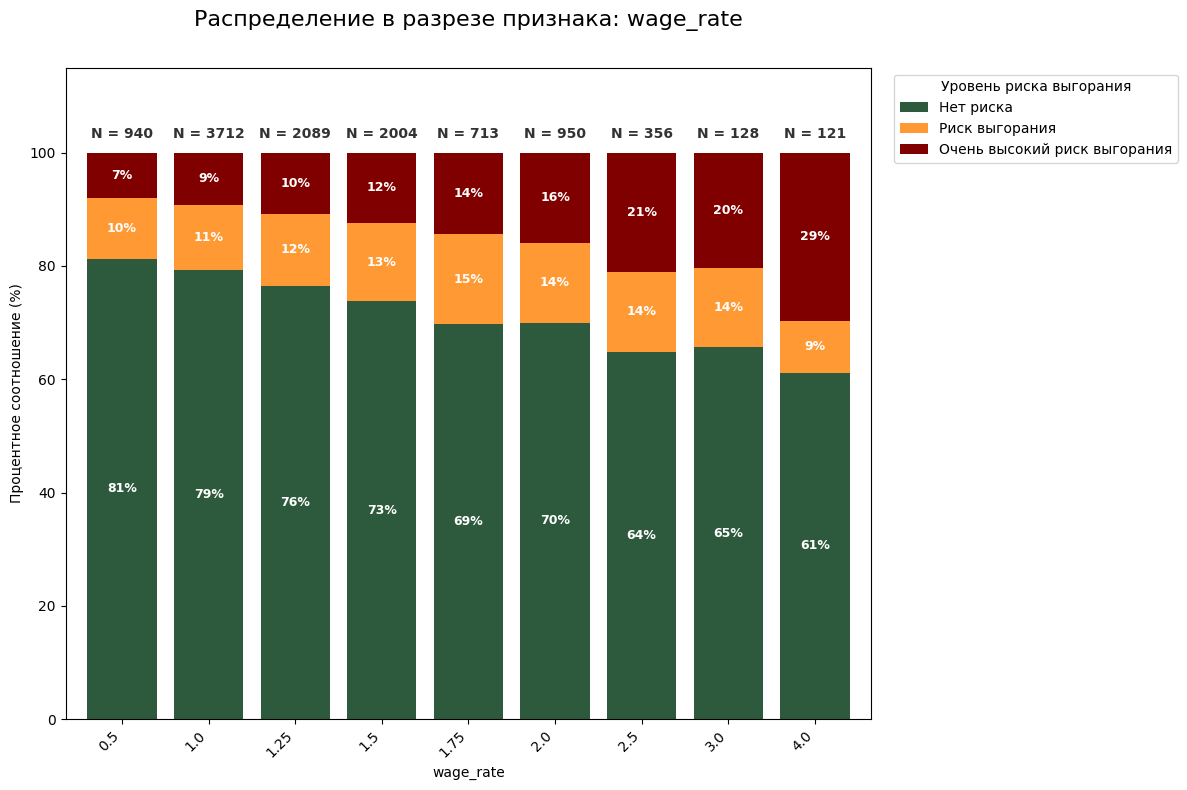


Анализ по категории: 'Очень высокий риск выгорания'
Порог Бонферрони (0.05 / 36): 0.00139
Найдено значимых различий: 19 из 36



,Пара групп,p-value,Значимо (Бонферрони)
5,0.5 vs 2.5,0.00,True
7,0.5 vs 4.0,0.00,True
12,1.0 vs 2.5,0.00,True
11,1.0 vs 2.0,0.00,True
20,1.25 vs 4.0,0.00,True
14,1.0 vs 4.0,0.00,True
18,1.25 vs 2.5,0.00,True
4,0.5 vs 2.0,0.00,True
25,1.5 vs 4.0,0.00,True
6,0.5 vs 3.0,0.00,True


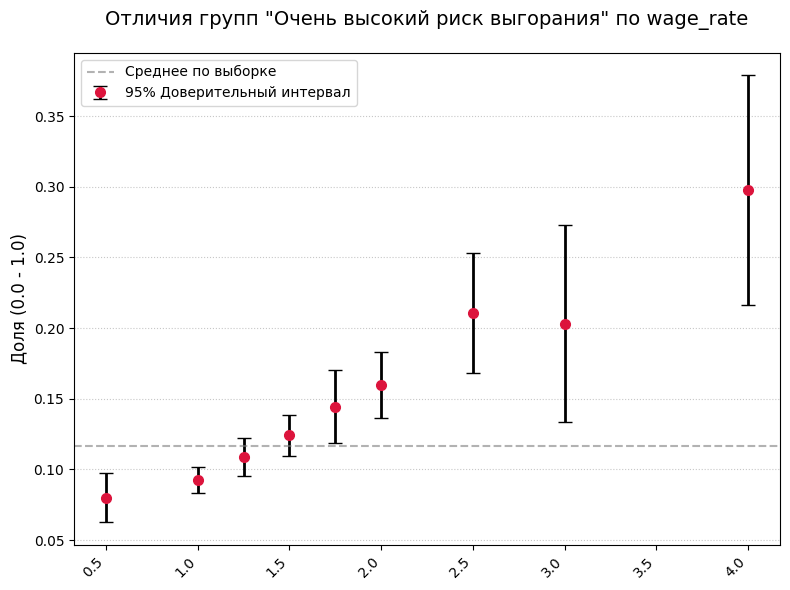

Анализ по категории: 'Риск выгорания'
Порог Бонферрони (0.05 / 36): 0.00139
Найдено значимых различий: 1 из 36



,Пара групп,p-value,Значимо (Бонферрони)
10,1.0 vs 1.75,0.00,True


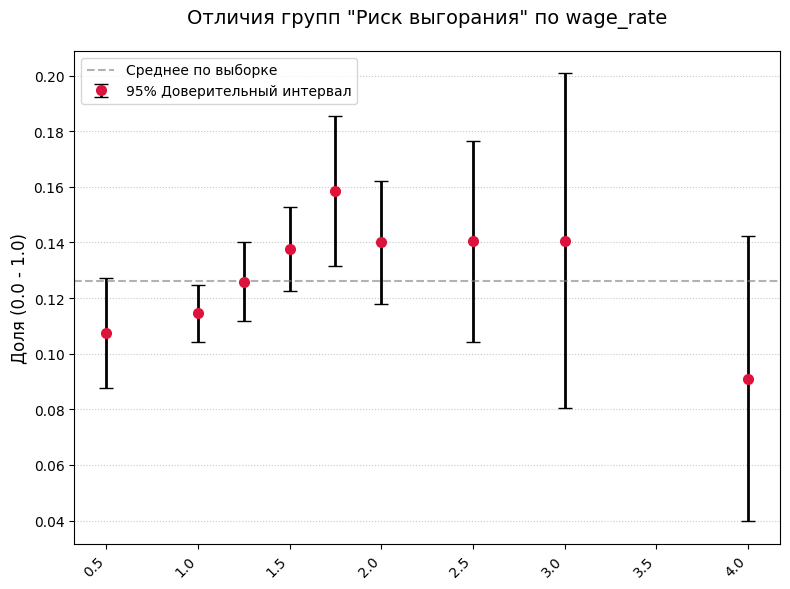

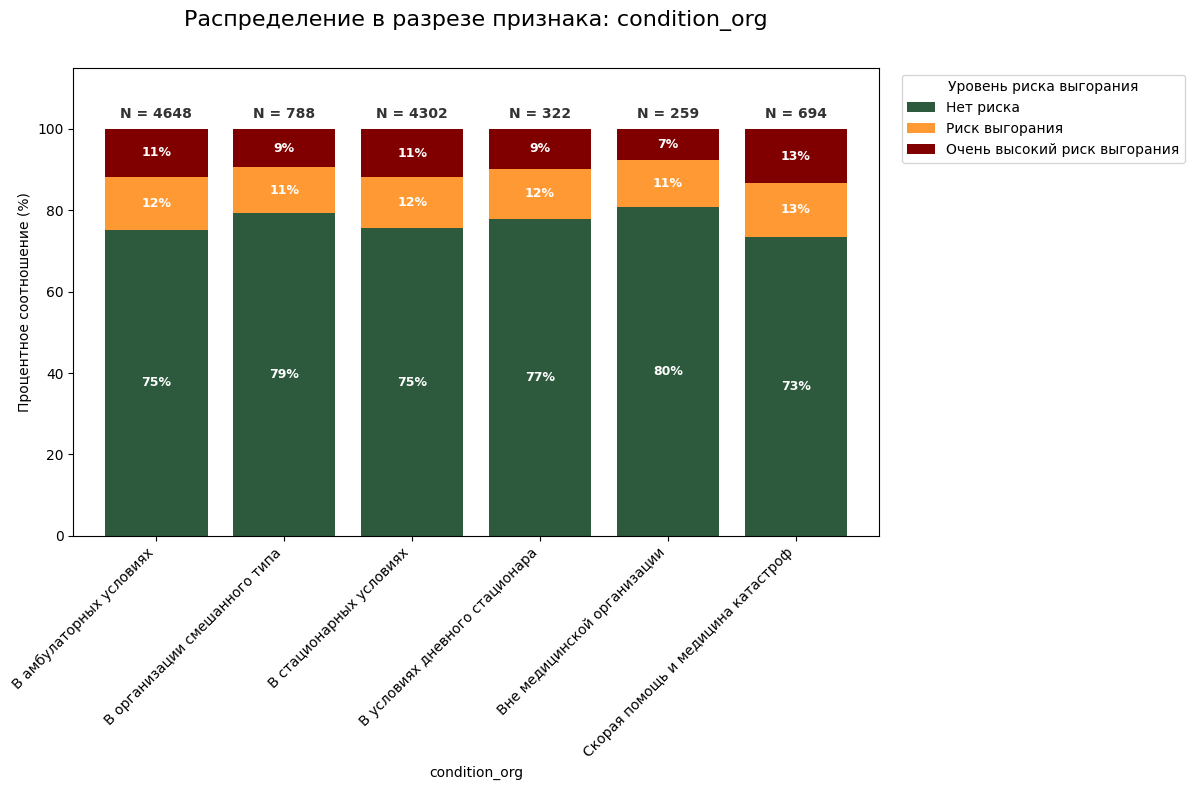


Анализ по категории: 'Очень высокий риск выгорания'
Порог Бонферрони (0.05 / 15): 0.00333
Найдено значимых различий: 0 из 15



,Пара групп,p-value,Значимо (Бонферрони)


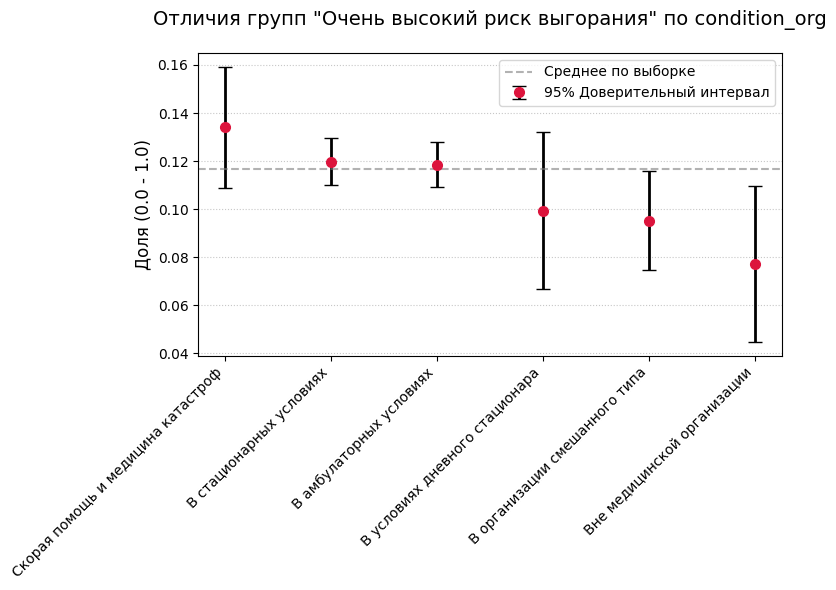

Анализ по категории: 'Риск выгорания'
Порог Бонферрони (0.05 / 15): 0.00333
Найдено значимых различий: 0 из 15



,Пара групп,p-value,Значимо (Бонферрони)


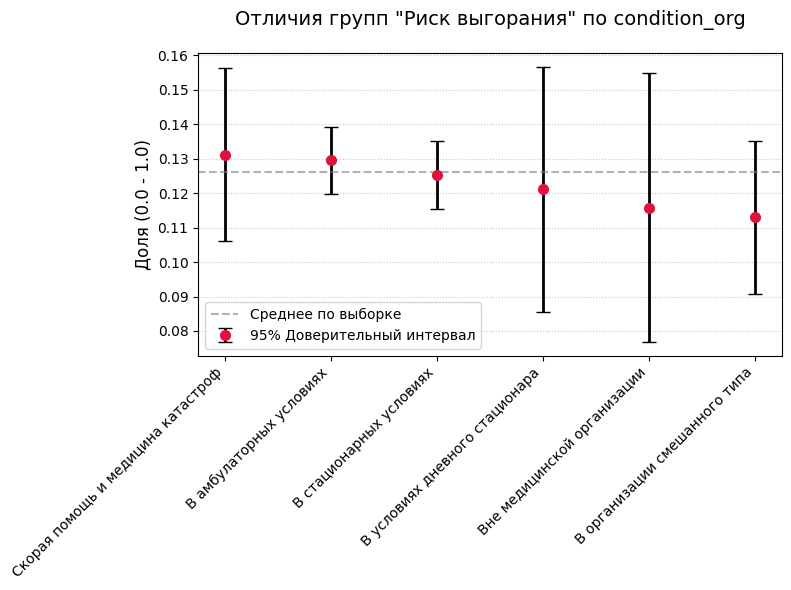

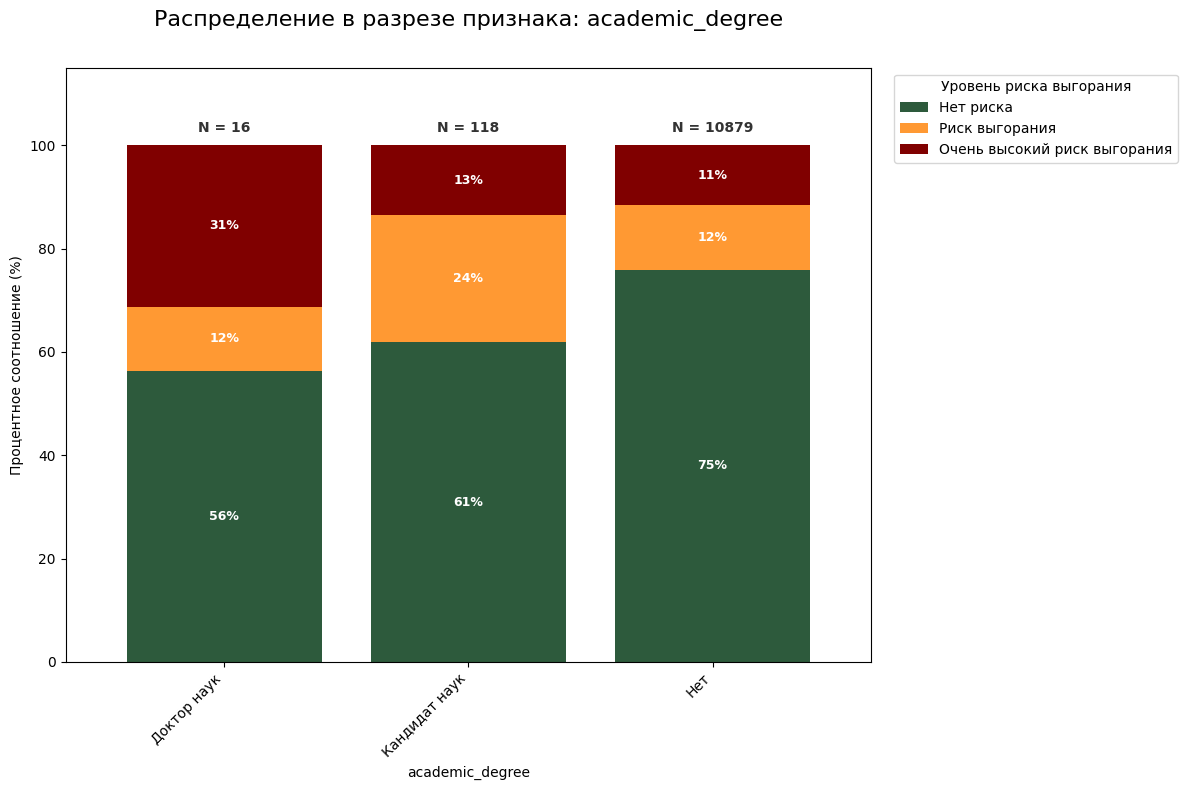


Анализ по категории: 'Очень высокий риск выгорания'
Порог Бонферрони (0.05 / 3): 0.01667
Найдено значимых различий: 0 из 3



,Пара групп,p-value,Значимо (Бонферрони)


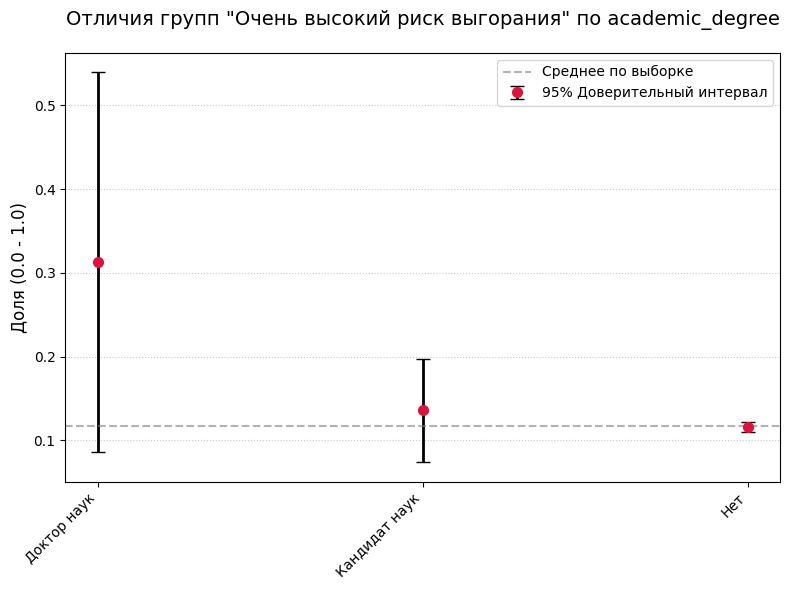

Анализ по категории: 'Риск выгорания'
Порог Бонферрони (0.05 / 3): 0.01667
Найдено значимых различий: 1 из 3



,Пара групп,p-value,Значимо (Бонферрони)
2,Кандидат наук vs Нет,0.00,True


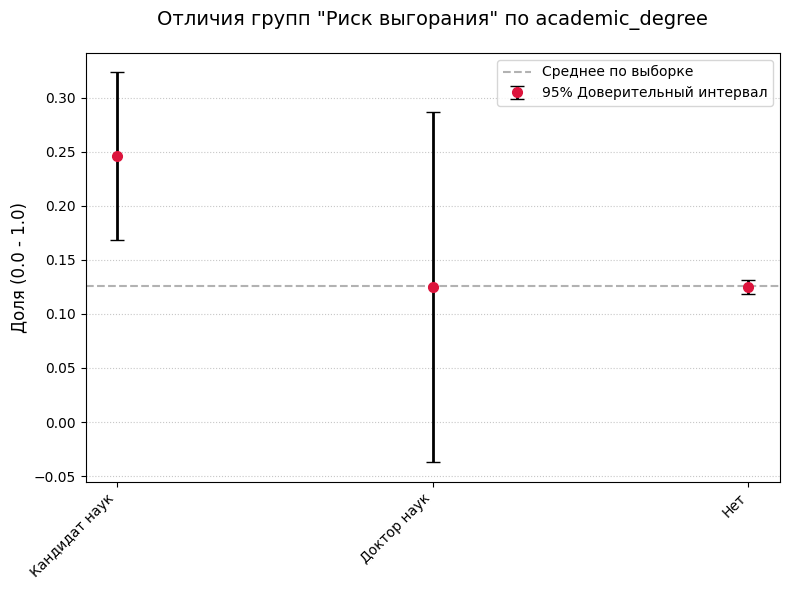

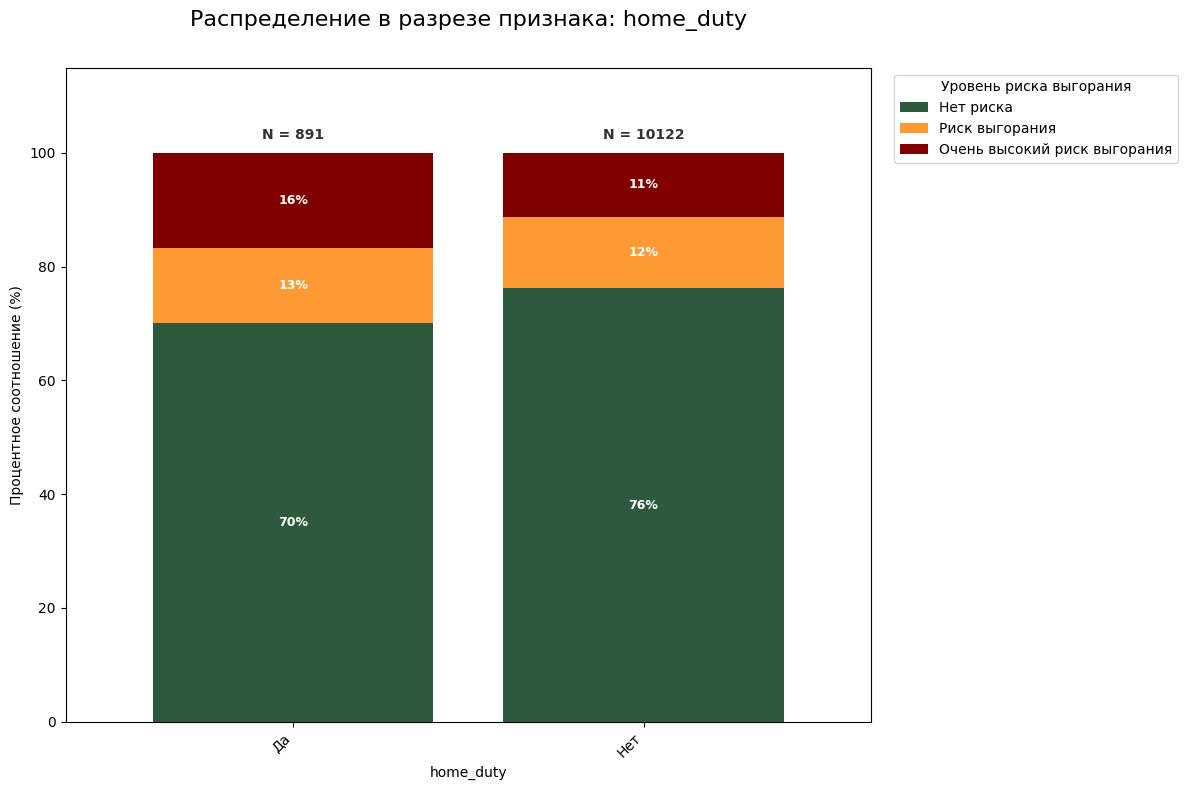


Анализ по категории: 'Очень высокий риск выгорания'
Порог Бонферрони (0.05 / 1): 0.05000
Найдено значимых различий: 1 из 1



,Пара групп,p-value,Значимо (Бонферрони)
0,Да vs Нет,0.00,True


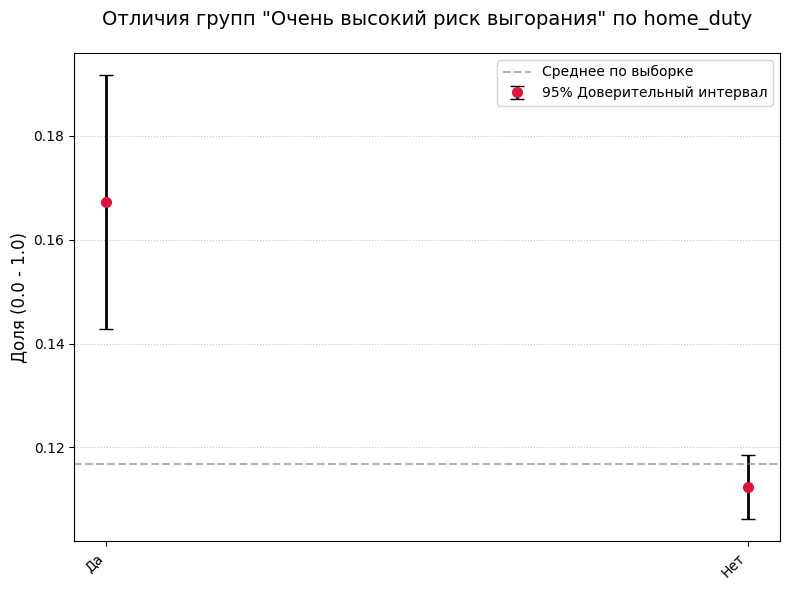

Анализ по категории: 'Риск выгорания'
Порог Бонферрони (0.05 / 1): 0.05000
Найдено значимых различий: 0 из 1



,Пара групп,p-value,Значимо (Бонферрони)


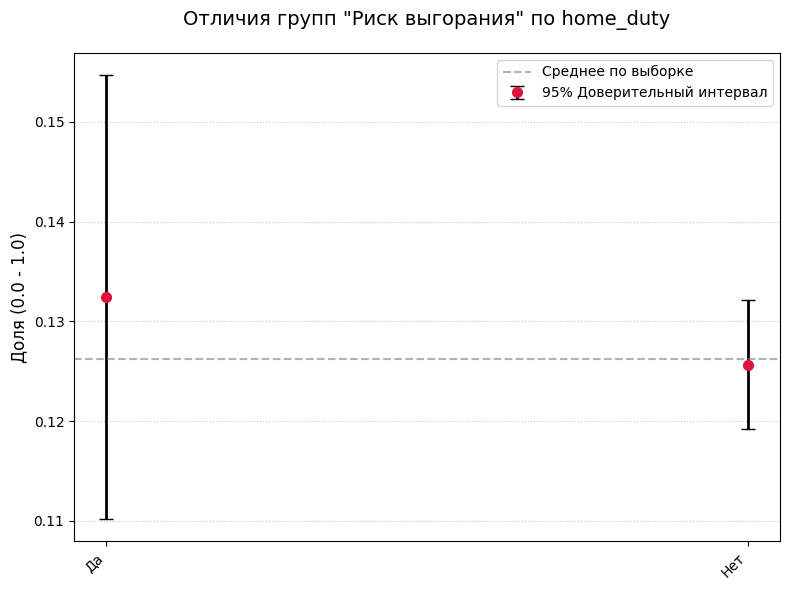

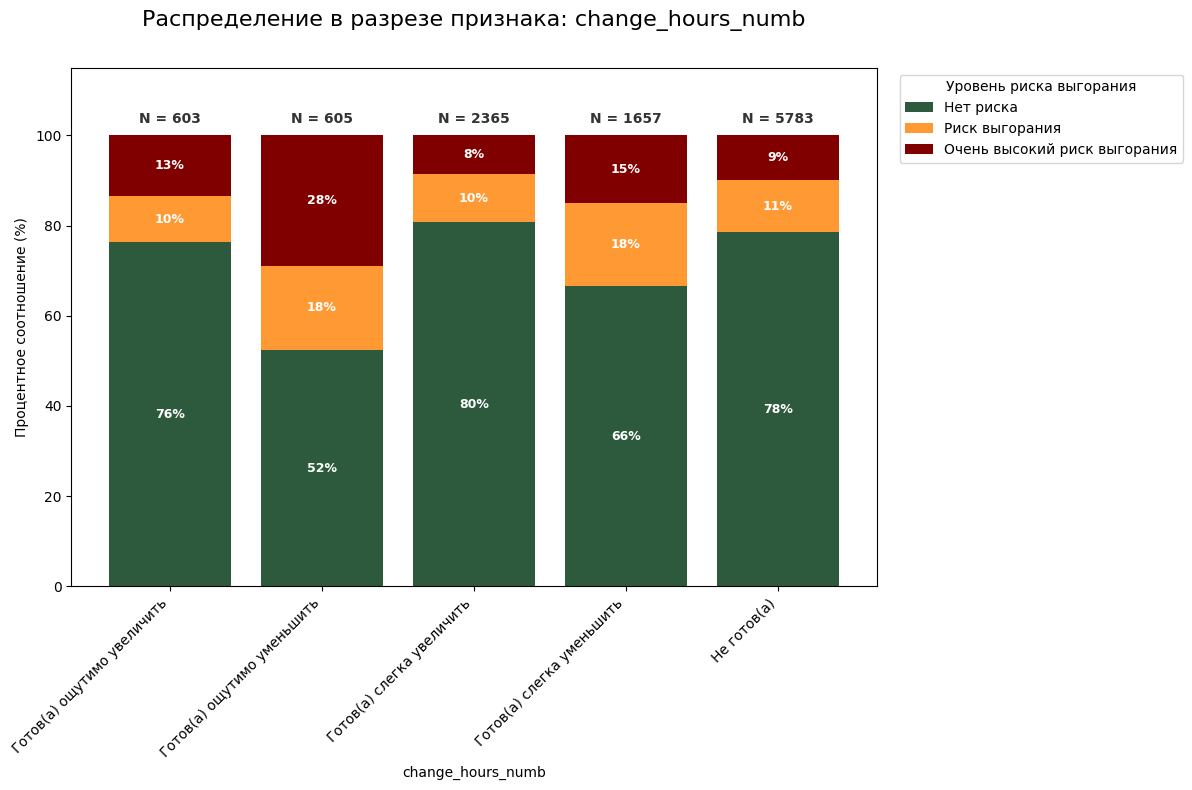


Анализ по категории: 'Очень высокий риск выгорания'
Порог Бонферрони (0.05 / 10): 0.00500
Найдено значимых различий: 7 из 10



,Пара групп,p-value,Значимо (Бонферрони)
0,Готов(а) ощутимо увеличить vs Готов(а) ощутимо...,0.00,True
4,Готов(а) ощутимо уменьшить vs Готов(а) слегка ...,0.00,True
5,Готов(а) ощутимо уменьшить vs Готов(а) слегка ...,0.00,True
6,Готов(а) ощутимо уменьшить vs Не готов(а),0.00,True
7,Готов(а) слегка увеличить vs Готов(а) слегка у...,0.00,True
9,Готов(а) слегка уменьшить vs Не готов(а),0.00,True
1,Готов(а) ощутимо увеличить vs Готов(а) слегка ...,0.00,True


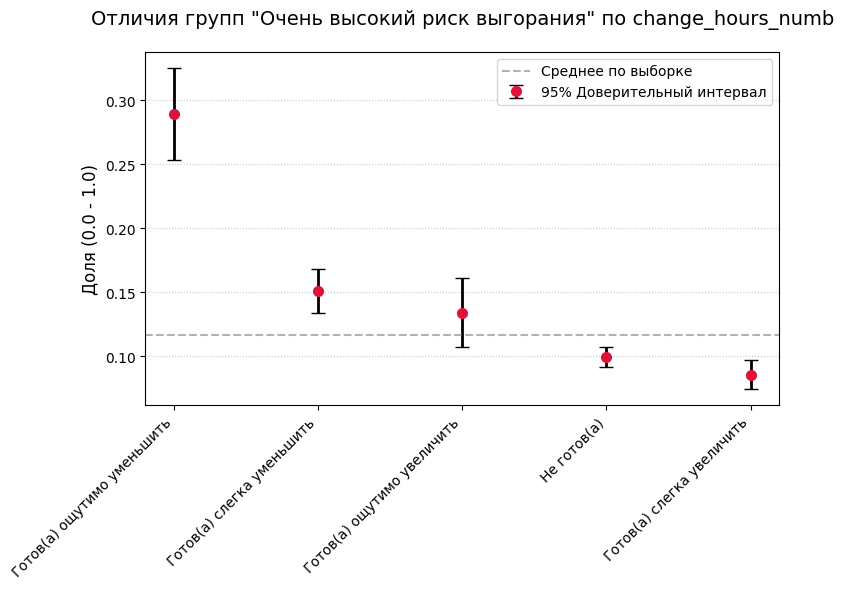

Анализ по категории: 'Риск выгорания'
Порог Бонферрони (0.05 / 10): 0.00500
Найдено значимых различий: 6 из 10



,Пара групп,p-value,Значимо (Бонферрони)
9,Готов(а) слегка уменьшить vs Не готов(а),0.00,True
7,Готов(а) слегка увеличить vs Готов(а) слегка у...,0.00,True
4,Готов(а) ощутимо уменьшить vs Готов(а) слегка ...,0.00,True
6,Готов(а) ощутимо уменьшить vs Не готов(а),0.00,True
2,Готов(а) ощутимо увеличить vs Готов(а) слегка ...,0.00,True
0,Готов(а) ощутимо увеличить vs Готов(а) ощутимо...,0.00,True


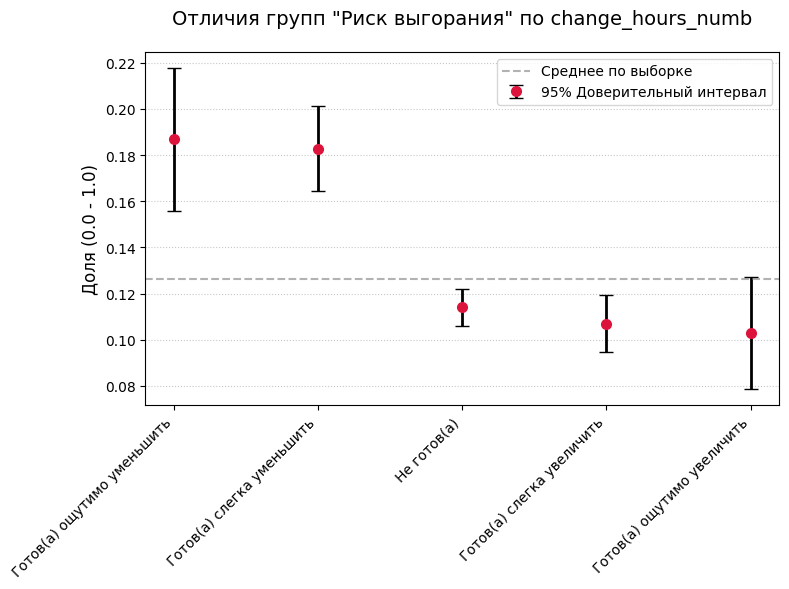

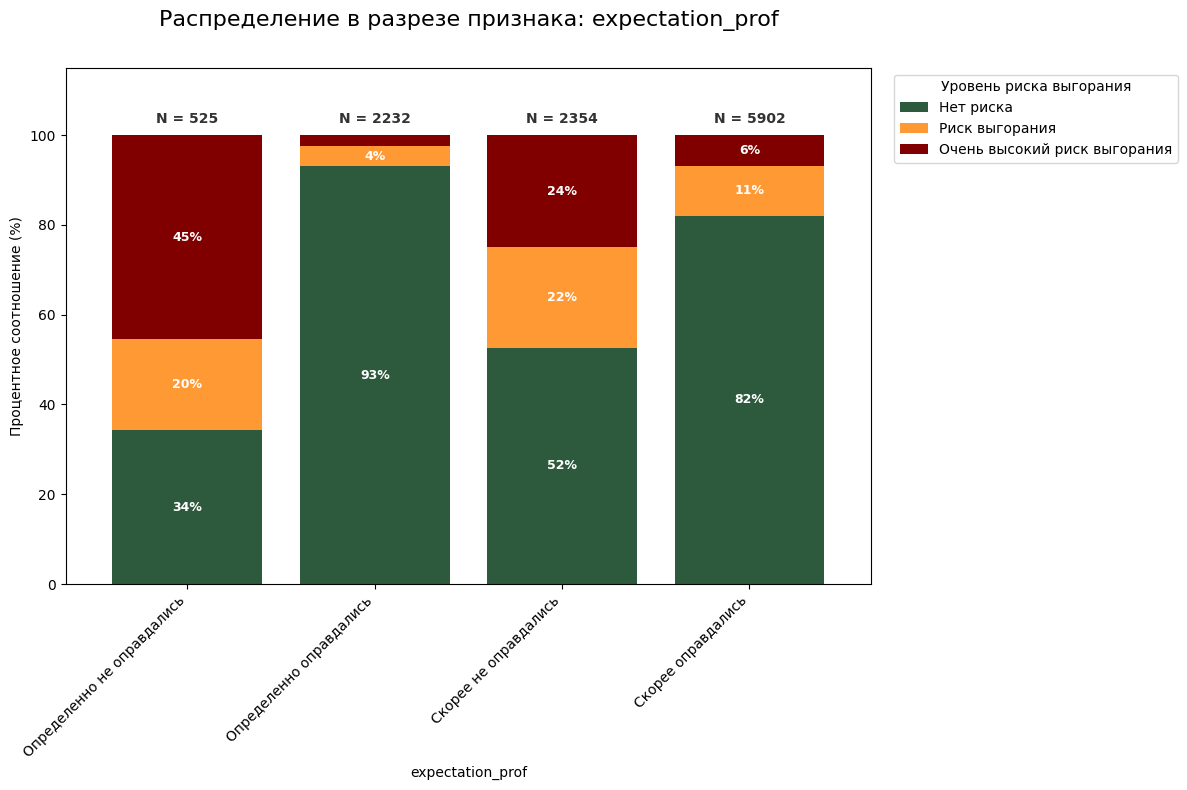


Анализ по категории: 'Очень высокий риск выгорания'
Порог Бонферрони (0.05 / 6): 0.00833
Найдено значимых различий: 6 из 6



,Пара групп,p-value,Значимо (Бонферрони)
0,Определенно не оправдались vs Определенно опра...,0.00,True
1,Определенно не оправдались vs Скорее не оправд...,0.00,True
2,Определенно не оправдались vs Скорее оправдались,0.00,True
3,Определенно оправдались vs Скорее не оправдались,0.00,True
4,Определенно оправдались vs Скорее оправдались,0.00,True
5,Скорее не оправдались vs Скорее оправдались,0.00,True


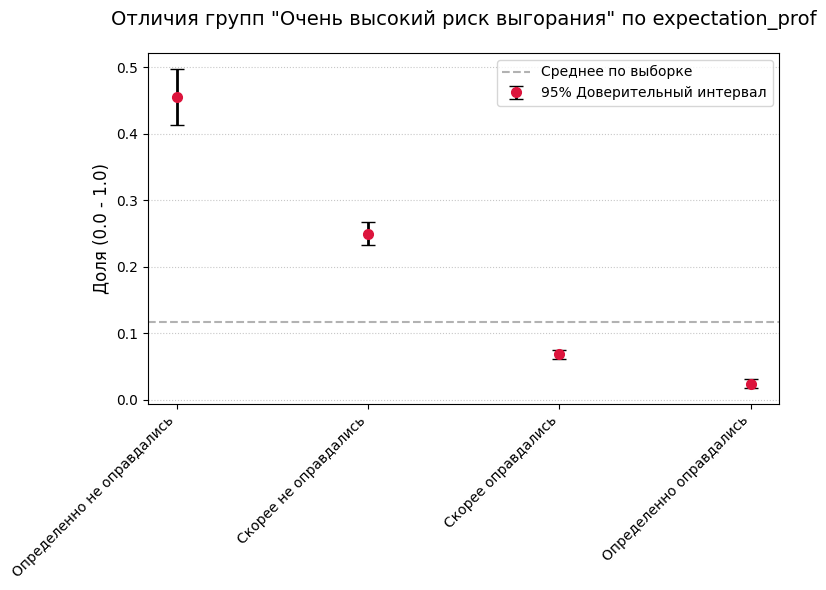

Анализ по категории: 'Риск выгорания'
Порог Бонферрони (0.05 / 6): 0.00833
Найдено значимых различий: 5 из 6



,Пара групп,p-value,Значимо (Бонферрони)
0,Определенно не оправдались vs Определенно опра...,0.00,True
2,Определенно не оправдались vs Скорее оправдались,0.00,True
3,Определенно оправдались vs Скорее не оправдались,0.00,True
4,Определенно оправдались vs Скорее оправдались,0.00,True
5,Скорее не оправдались vs Скорее оправдались,0.00,True


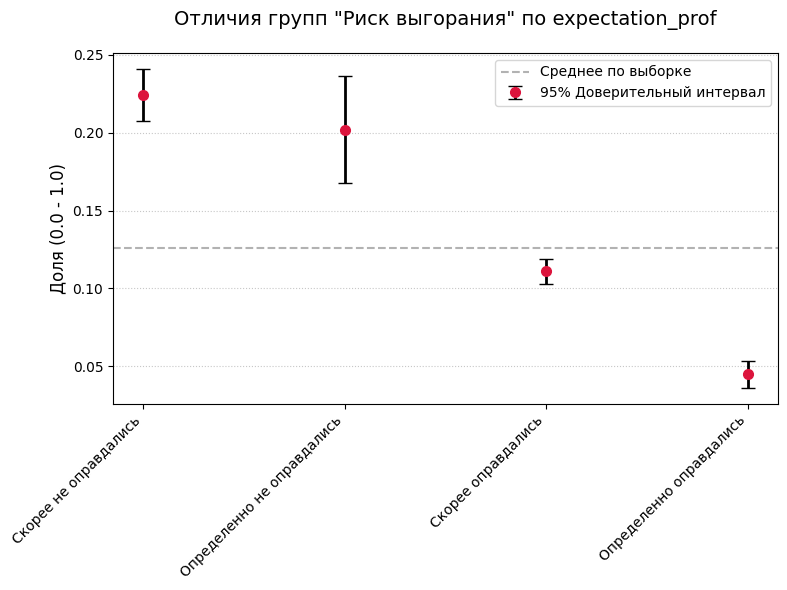

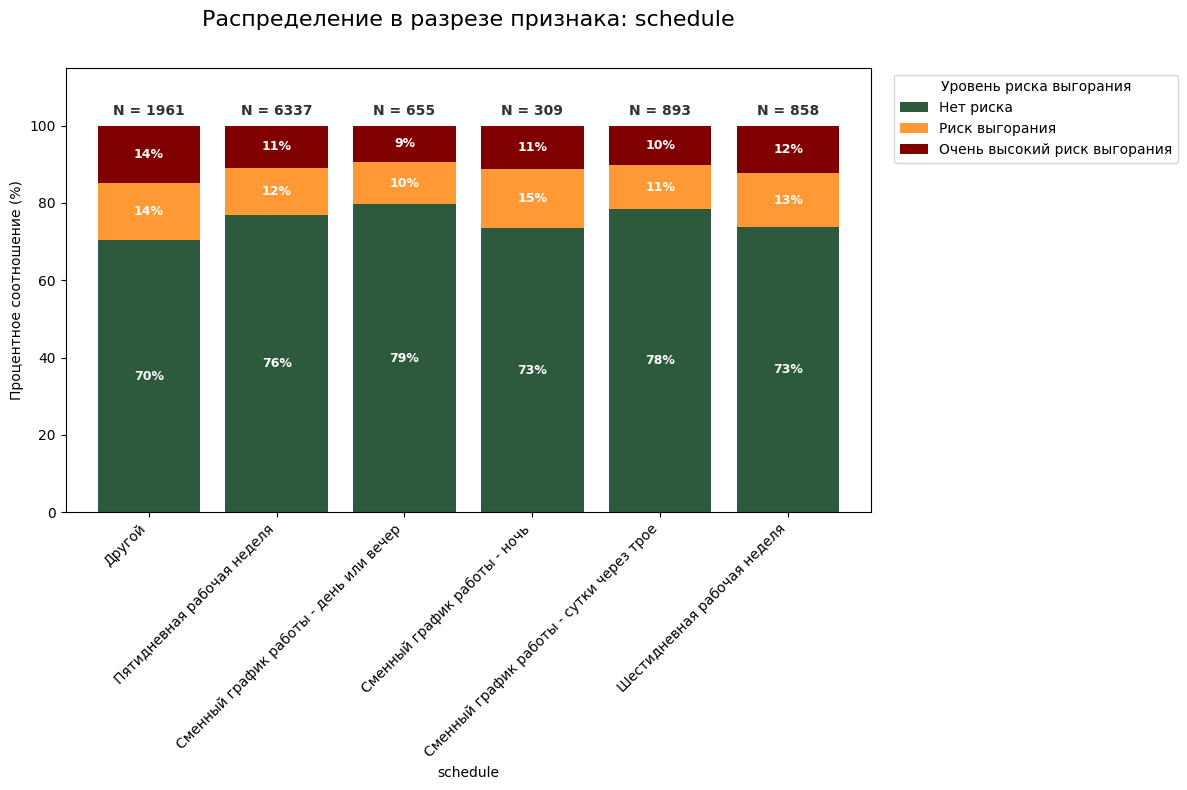


Анализ по категории: 'Очень высокий риск выгорания'
Порог Бонферрони (0.05 / 15): 0.00333
Найдено значимых различий: 3 из 15



,Пара групп,p-value,Значимо (Бонферрони)
0,Другой vs Пятидневная рабочая неделя,0.00,True
1,Другой vs Сменный график работы - день или вечер,0.00,True
3,Другой vs Сменный график работы - сутки через ...,0.00,True


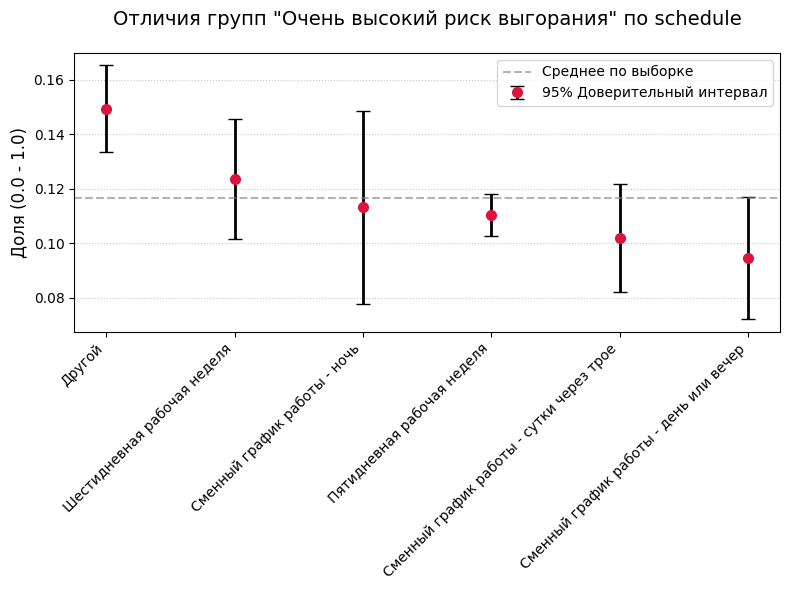

Анализ по категории: 'Риск выгорания'
Порог Бонферрони (0.05 / 15): 0.00333
Найдено значимых различий: 1 из 15



,Пара групп,p-value,Значимо (Бонферрони)
0,Другой vs Пятидневная рабочая неделя,0.00,True


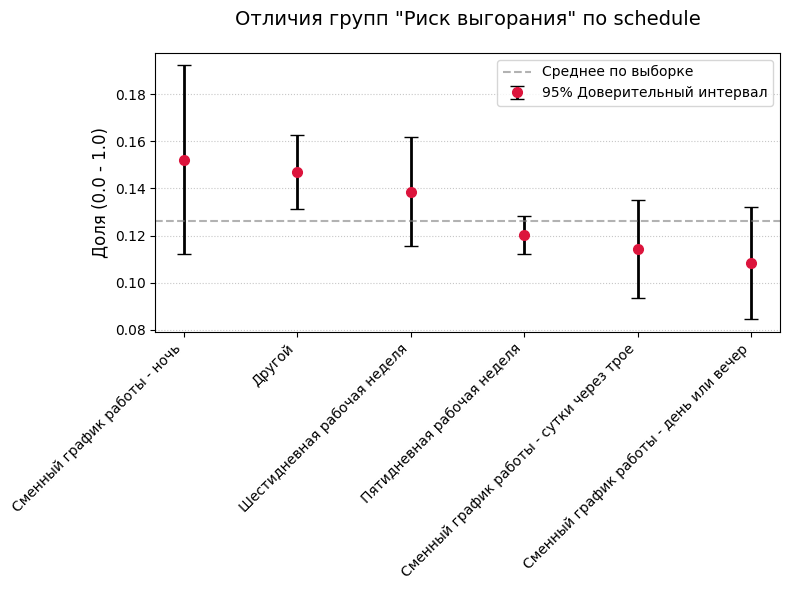

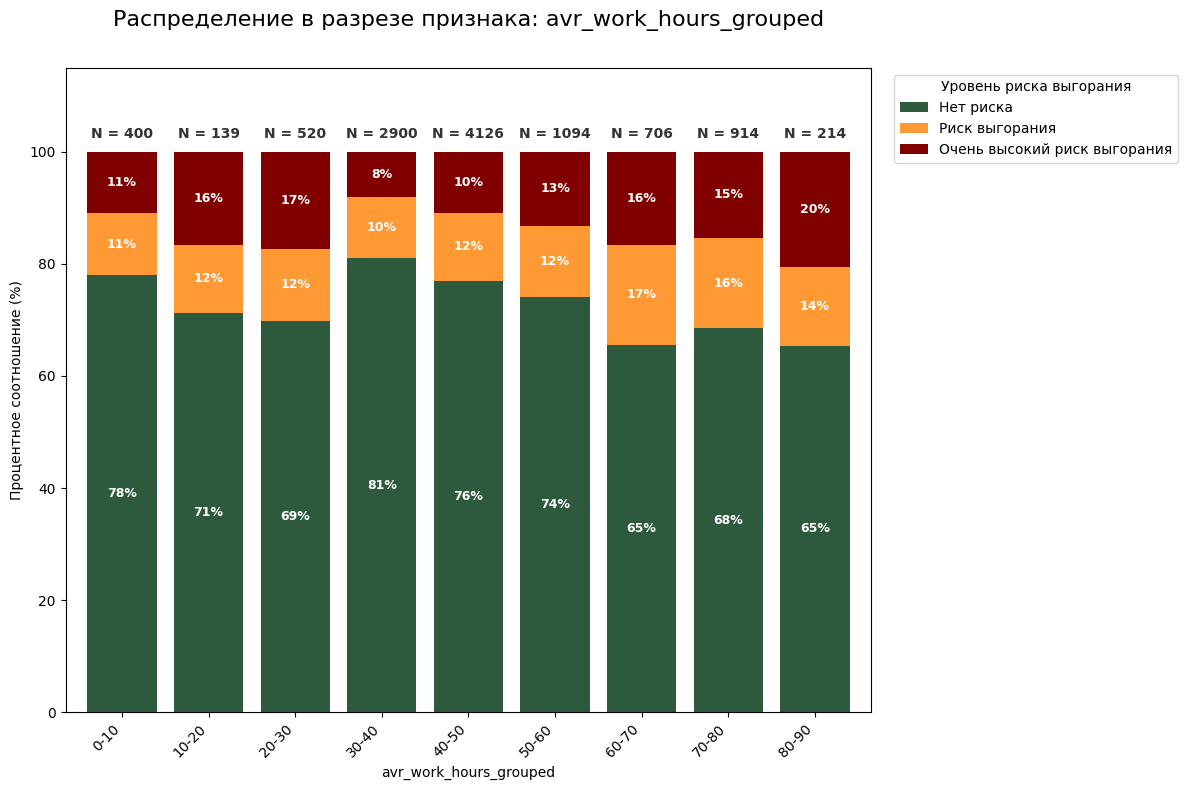


Анализ по категории: 'Очень высокий риск выгорания'
Порог Бонферрони (0.05 / 36): 0.00139
Найдено значимых различий: 11 из 36



,Пара групп,p-value,Значимо (Бонферрони)
15,20-30 vs 30-40,0.00,True
25,30-40 vs 80-90,0.00,True
24,30-40 vs 70-80,0.00,True
23,30-40 vs 60-70,0.00,True
22,30-40 vs 50-60,0.00,True
27,40-50 vs 60-70,0.00,True
29,40-50 vs 80-90,0.00,True
16,20-30 vs 40-50,0.00,True
21,30-40 vs 40-50,0.00,True
28,40-50 vs 70-80,0.00,True


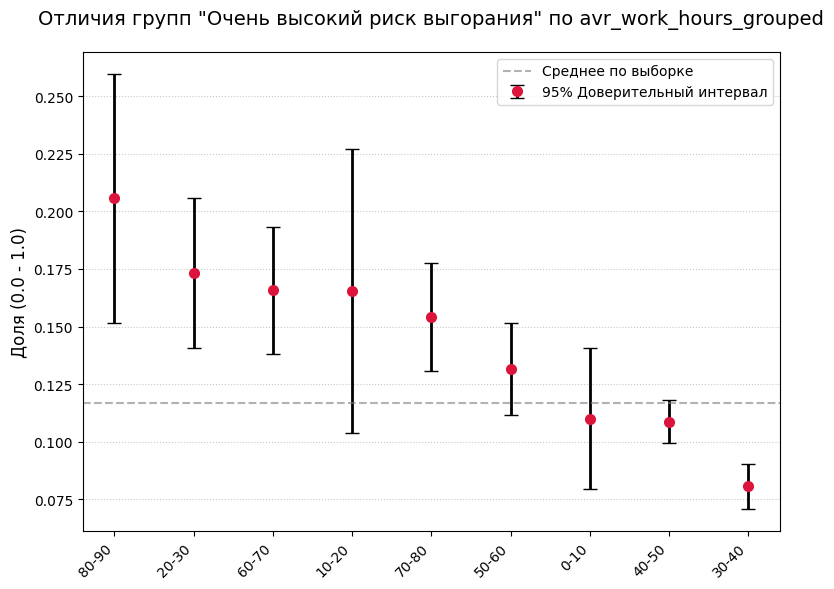

Анализ по категории: 'Риск выгорания'
Порог Бонферрони (0.05 / 36): 0.00139
Найдено значимых различий: 3 из 36



,Пара групп,p-value,Значимо (Бонферрони)
23,30-40 vs 60-70,0.00,True
24,30-40 vs 70-80,0.00,True
27,40-50 vs 60-70,0.00,True


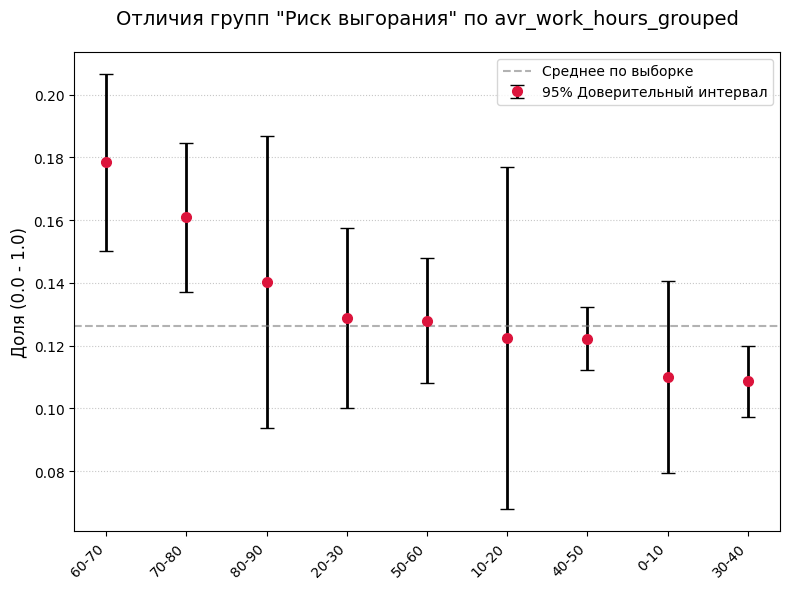

In [ ]:
for col in columns:
  get_differential_burnout_report(col)